In [1]:
!pip install --upgrade pip
!pip install --quiet openmeteo-requests requests-cache retry-requests numpy pandas matplotlib seaborn plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 37.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
#Configuración del cliente Open-Meteo
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=3, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

#Coordenadas de ciudades
ciudades = {
    #"Bogotá": (4.7110, -74.0721)
    "Medellín": (6.2442, -75.5812),
    #"Cali": (3.4516, -76.5320),
    #"Barranquilla": (10.9685, -74.7813),
    #"Barcelona": (41.3888, 2.159)
}

# Descarga de datos de clima y aire
df_list = []

for ciudad, (lat, lon) in ciudades.items():
    # Clima
    url_weather = "https://historical-forecast-api.open-meteo.com/v1/forecast"
    params_weather = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2022-01-01",
	      "end_date": "2025-11-02",
        "hourly": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m",
            "surface_pressure", "shortwave_radiation",
            "precipitation", "cloud_cover", "evapotranspiration",
            "soil_temperature_0cm", "sunshine_duration", "uv_index",
            "boundary_layer_height","vapour_pressure_deficit","soil_moisture_0_to_1cm"
                    ]
    }

    response_w = openmeteo.weather_api(url_weather, params=params_weather)[0]
    hourly_w = response_w.Hourly()

    df_weather = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(hourly_w.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly_w.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly_w.Interval()),
            inclusive="left"
        ),
        "temperature": hourly_w.Variables(0).ValuesAsNumpy(),
        "humidity": hourly_w.Variables(1).ValuesAsNumpy(),
        "wind_speed": hourly_w.Variables(2).ValuesAsNumpy(),
        "pressure": hourly_w.Variables(3).ValuesAsNumpy(),
        "shortwave_radiation": hourly_w.Variables(4).ValuesAsNumpy(),
        "precipitation": hourly_w.Variables(5).ValuesAsNumpy(),
        "cloud_cover": hourly_w.Variables(6).ValuesAsNumpy(),
        "et0": hourly_w.Variables(7).ValuesAsNumpy(),
        "soil_temp_0cm": hourly_w.Variables(8).ValuesAsNumpy(),
        "sunshine_duration": hourly_w.Variables(9).ValuesAsNumpy(),
        "uv_index": hourly_w.Variables(10).ValuesAsNumpy(),
        "bound_lay_hei": hourly_w.Variables(11).ValuesAsNumpy(),
        "vapour_pressure": hourly_w.Variables(12).ValuesAsNumpy(),
        "soil_mois": hourly_w.Variables(13).ValuesAsNumpy()


    })
    #Calidad del Aire
    url_air = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params_air = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2022-01-01",
	      "end_date": "2025-11-02",
        "hourly":["pm2_5", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone",
         "aerosol_optical_depth", "methane", "ammonia", "olive_pollen", "residential_elementary_carbon", "nitrogen_monoxide"]
    }

    response_a = openmeteo.weather_api(url_air, params=params_air)[0]
    hourly_a = response_a.Hourly()

    df_air = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(hourly_a.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly_a.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly_a.Interval()),
            inclusive="left"
        ),
        "pm2_5": hourly_a.Variables(0).ValuesAsNumpy(),
        "co": hourly_a.Variables(1).ValuesAsNumpy(),
        "no2": hourly_a.Variables(2).ValuesAsNumpy(),
        "so2": hourly_a.Variables(3).ValuesAsNumpy(),
        "o3": hourly_a.Variables(4).ValuesAsNumpy(),
        "aero_op": hourly_a.Variables(5).ValuesAsNumpy(),
        "ch4": hourly_a.Variables(6).ValuesAsNumpy(),
        "nh3": hourly_a.Variables(7).ValuesAsNumpy(),
        "olive_pol": hourly_a.Variables(8).ValuesAsNumpy(),
        "res_ele_carb": hourly_a.Variables(9).ValuesAsNumpy(),
        "no": hourly_a.Variables(10).ValuesAsNumpy()

    })

    #Unión por fecha
    df_full = pd.merge_asof(df_weather.sort_values("date"), df_air.sort_values("date"), on="date")
   # df["city"] = ciudad
    #df_list.append(df)

#Unir todas las ciudades
#df_full = pd.concat(df_list, ignore_index=True)


In [ ]:
display(df_full.tail(24))

,date,temperature,humidity,wind_speed,pressure,shortwave_radiation,precipitation,cloud_cover,et0,soil_temp_0cm,...,no2,so2,o3,uv_index_y,aero_op,ch4,nh3,olive_pol,res_ele_carb,no
33624,2025-11-02 00:00:00+00:00,27.962500,54.0,5.623380,855.486572,0.0,0.9,100.0,-0.00,24.312500,...,45.099998,9.8,37.0,0.00,0.13,1527.0,NaN,NaN,NaN,0.0
33625,2025-11-02 01:00:00+00:00,26.812500,57.0,4.452954,856.225586,0.0,0.0,100.0,0.02,23.662500,...,44.500000,11.7,33.0,0.00,0.15,1565.0,NaN,NaN,NaN,2.5
33626,2025-11-02 02:00:00+00:00,25.712500,59.0,5.241679,856.813538,0.0,0.0,100.0,0.02,23.162500,...,43.700001,14.2,27.0,0.00,0.16,1599.0,NaN,NaN,NaN,6.0
33627,2025-11-02 03:00:00+00:00,24.562500,64.0,5.315336,857.119141,0.0,0.0,100.0,0.02,22.712500,...,42.700001,15.6,22.0,0.00,0.16,1621.0,NaN,NaN,NaN,7.9
33628,2025-11-02 04:00:00+00:00,23.412500,70.0,4.379589,856.912476,0.0,0.1,100.0,0.02,22.262499,...,41.799999,14.9,19.0,0.00,0.18,1620.0,NaN,NaN,NaN,6.9
33629,2025-11-02 05:00:00+00:00,22.812500,75.0,2.160000,856.626282,0.0,0.0,100.0,0.02,21.712500,...,40.799999,13.2,18.0,0.00,0.18,1607.0,NaN,NaN,NaN,4.5
33630,2025-11-02 06:00:00+00:00,23.162500,72.0,1.800000,855.778381,0.0,0.0,100.0,-0.00,21.512499,...,39.200001,11.5,17.0,0.00,0.17,1604.0,NaN,NaN,NaN,2.4
33631,2025-11-02 07:00:00+00:00,22.462500,78.0,1.138420,855.190735,0.0,0.0,100.0,0.01,20.962500,...,36.500000,10.2,17.0,0.00,0.16,1624.0,NaN,NaN,NaN,1.2
33632,2025-11-02 08:00:00+00:00,22.212500,77.0,1.297998,854.817627,0.0,0.0,70.0,-0.00,20.262499,...,33.099998,9.0,17.0,0.00,0.17,1654.0,NaN,NaN,NaN,0.4
33633,2025-11-02 09:00:00+00:00,22.062500,76.0,1.938659,854.661255,0.0,0.0,68.0,-0.00,19.962500,...,29.900000,8.1,20.0,0.00,0.18,1679.0,NaN,NaN,NaN,0.0


In [3]:
# Asegúrate de que la columna de fecha sea datetime
df_full["date"] = pd.to_datetime(df_full["date"])

# Extraer las últimas 24 horas
ultimo_dia = df_full.iloc[-24:].copy()
df_ultimo_dia = ultimo_dia.reset_index(drop=True)

# Eliminar estas 24 horas del dataset original
df_full = df_full.iloc[:-24].reset_index(drop=True)

# Revisar
print("Dataset original después de quitar último día:")
display(df_full.tail())
print("\nNuevo dataset del último día:")
display(df_ultimo_dia.head())


Dataset original después de quitar último día:


,date,temperature,humidity,wind_speed,pressure,shortwave_radiation,precipitation,cloud_cover,et0,soil_temp_0cm,...,co,no2,so2,o3,aero_op,ch4,nh3,olive_pol,res_ele_carb,no
33619,2025-11-01 19:00:00+00:00,27.312500,71.0,3.600000,855.186218,428.0,0.0,100.0,0.37,27.912500,...,186.0,0.7,2.0,96.0,0.13,1382.0,NaN,NaN,NaN,0.2
33620,2025-11-01 20:00:00+00:00,27.162500,68.0,3.219938,854.269226,306.0,0.0,100.0,0.25,26.912500,...,152.0,0.2,2.1,96.0,0.13,1388.0,NaN,NaN,NaN,0.1
33621,2025-11-01 21:00:00+00:00,27.012499,67.0,3.319036,854.369141,200.0,0.0,100.0,0.16,26.462500,...,268.0,3.6,2.7,90.0,0.15,1405.0,NaN,NaN,NaN,0.1
33622,2025-11-01 22:00:00+00:00,26.812500,68.0,2.305125,854.954346,98.0,0.0,100.0,0.08,25.462500,...,673.0,15.2,4.5,71.0,0.14,1439.0,NaN,NaN,NaN,0.1
33623,2025-11-01 23:00:00+00:00,25.712500,76.0,1.527351,855.289001,13.0,0.2,100.0,0.02,23.862499,...,1228.0,30.6,6.9,45.0,0.14,1485.0,NaN,NaN,NaN,0.1



Nuevo dataset del último día:


,date,temperature,humidity,wind_speed,pressure,shortwave_radiation,precipitation,cloud_cover,et0,soil_temp_0cm,...,co,no2,so2,o3,aero_op,ch4,nh3,olive_pol,res_ele_carb,no
0,2025-11-02 00:00:00+00:00,27.9625,54.0,5.623380,855.486572,0.0,0.9,100.0,-0.00,24.312500,...,1640.0,45.099998,9.8,37.0,0.13,1527.0,NaN,NaN,NaN,0.0
1,2025-11-02 01:00:00+00:00,26.8125,57.0,4.452954,856.225586,0.0,0.0,100.0,0.02,23.662500,...,1823.0,44.500000,11.7,33.0,0.15,1565.0,NaN,NaN,NaN,2.5
2,2025-11-02 02:00:00+00:00,25.7125,59.0,5.241679,856.813538,0.0,0.0,100.0,0.02,23.162500,...,1863.0,43.700001,14.2,27.0,0.16,1599.0,NaN,NaN,NaN,6.0
3,2025-11-02 03:00:00+00:00,24.5625,64.0,5.315336,857.119141,0.0,0.0,100.0,0.02,22.712500,...,1736.0,42.700001,15.6,22.0,0.16,1621.0,NaN,NaN,NaN,7.9
4,2025-11-02 04:00:00+00:00,23.4125,70.0,4.379589,856.912476,0.0,0.1,100.0,0.02,22.262499,...,1325.0,41.799999,14.9,19.0,0.18,1620.0,NaN,NaN,NaN,6.9


In [ ]:
display(df_full.tail())

,date,temperature,humidity,wind_speed,pressure,shortwave_radiation,precipitation,cloud_cover,et0,soil_temp_0cm,sunshine_duration,uv_index,bound_lay_hei,vapour_pressure,soil_mois
33619,2025-11-01 19:00:00+00:00,27.312500,71.0,3.600000,855.186218,428.0,0.0,100.0,0.37,27.912500,1932.440186,4.20,690.0,1.052299,0.304
33620,2025-11-01 20:00:00+00:00,27.162500,68.0,3.219938,854.269226,306.0,0.0,100.0,0.25,26.912500,0.000000,3.30,515.0,1.151099,0.302
33621,2025-11-01 21:00:00+00:00,27.012499,67.0,3.319036,854.369141,200.0,0.0,100.0,0.16,26.462500,0.000000,2.60,310.0,1.176725,0.300
33622,2025-11-01 22:00:00+00:00,26.812500,68.0,2.305125,854.954346,98.0,0.0,100.0,0.08,25.462500,0.000000,1.40,15.0,1.127754,0.300
33623,2025-11-01 23:00:00+00:00,25.712500,76.0,1.527351,855.289001,13.0,0.2,100.0,0.02,23.862499,0.000000,0.15,15.0,0.792658,0.318


In [ ]:
"""print("Cantidad de nulos por columna:")
print(df_full.isnull().sum())

print("\nPorcentaje de nulos por columna:")
print((df_full.isnull().sum() / len(df_full) * 100).round(2))

print("\n¿Hay algún NaN en el DataFrame?")
print(df_full.isna().any().any())

print("\nFilas con al menos un NaN:")
print(df_full[df_full.isnull().any(axis=1)].head(10))

print("\nResumen general del DataFrame:")
print(df_full.info())
"""

'print("Cantidad de nulos por columna:")\nprint(df_full.isnull().sum())\n\nprint("\nPorcentaje de nulos por columna:")\nprint((df_full.isnull().sum() / len(df_full) * 100).round(2))\n\nprint("\n¿Hay algún NaN en el DataFrame?")\nprint(df_full.isna().any().any())\n\nprint("\nFilas con al menos un NaN:")\nprint(df_full[df_full.isnull().any(axis=1)].head(10))\n\nprint("\nResumen general del DataFrame:")\nprint(df_full.info())\n'

**LIBRERIAS IMPORTANTES**

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ***MODELO REGRESIÓN LINEAL TEMPERATURA***

In [29]:
features_reducidas = [
    "soil_temp_0cm",
    "vapour_pressure",
    "shortwave_radiation",
    "pressure",
    "wind_speed"
]

df = df_full.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

target = "temperature"

# Variables de estacionalidad
df["hour"] = df["date"].dt.hour
df["day_of_year"] = df["date"].dt.dayofyear
df["month"] = df["date"].dt.month

df["sin_day"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["cos_day"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
df["sin_hour"] = np.sin(2 * np.pi * df["hour"] / 24)
df["cos_hour"] = np.cos(2 * np.pi * df["hour"] / 24)

# Selección final de features
final_features = features_reducidas + ["sin_day", "cos_day", "sin_hour", "cos_hour"]

# Quitar filas con NaNs
df = df.dropna(subset=final_features + [target])

# Definir X e y
X = df[final_features]
y = df[target]

# Ahora X e y están listos para entrenar cualquier modelo hora por hora
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
dates_test = df["date"].iloc[-len(y_test):]

Resultados Regresión Lineal
R² CV promedio: 0.9805
RMSE CV promedio: 0.4736
MAE CV promedio: 0.3695
R² Test: 0.8688
RMSE Test: 1.1014
MAE Test: 0.9408


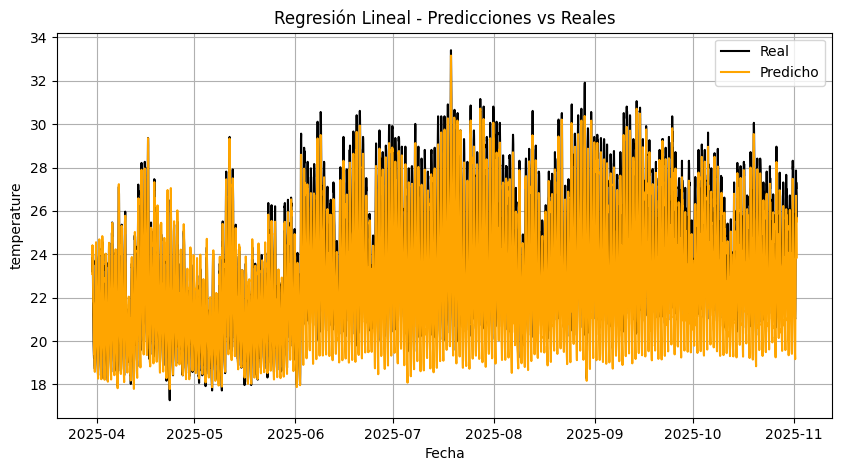

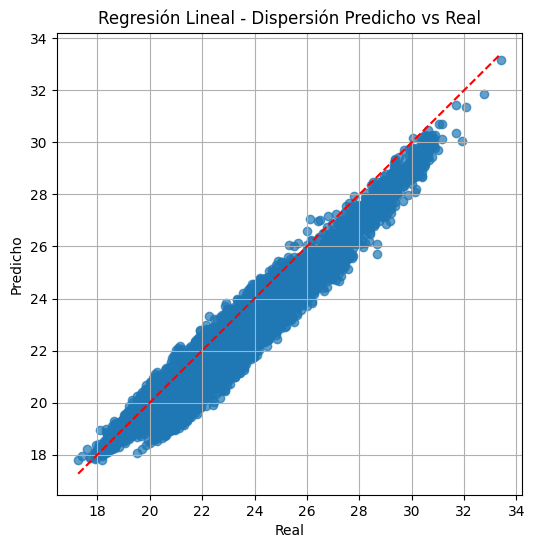

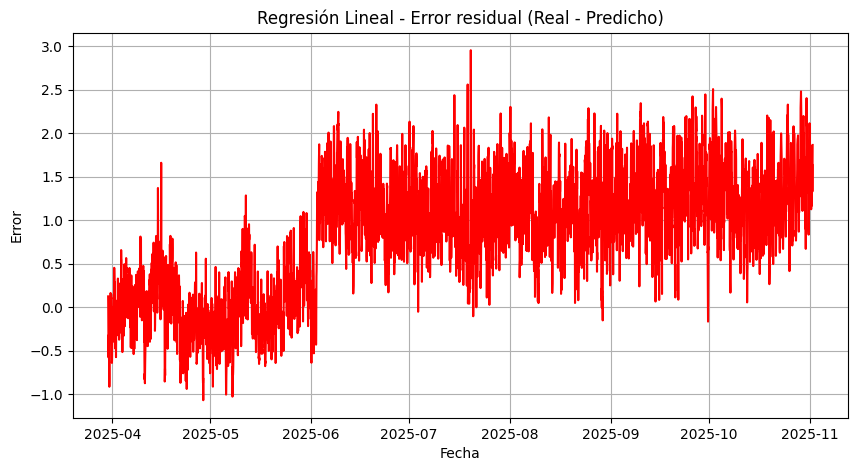

                       Fecha Predicción_Temperatura
0  2025-11-02 00:00:00+00:00                   23.7
1  2025-11-02 01:00:00+00:00                   23.0
2  2025-11-02 02:00:00+00:00                   22.3
3  2025-11-02 03:00:00+00:00                   21.7
4  2025-11-02 04:00:00+00:00                   21.1
5  2025-11-02 05:00:00+00:00                   20.7
6  2025-11-02 06:00:00+00:00                   20.4
7  2025-11-02 07:00:00+00:00                   20.1
8  2025-11-02 08:00:00+00:00                   19.8
9  2025-11-02 09:00:00+00:00                   19.5
10 2025-11-02 10:00:00+00:00                   19.3
11 2025-11-02 11:00:00+00:00                   19.2
12 2025-11-02 12:00:00+00:00                   20.3
13 2025-11-02 13:00:00+00:00                   21.7
14 2025-11-02 14:00:00+00:00                   22.5
15 2025-11-02 15:00:00+00:00                   23.9
16 2025-11-02 16:00:00+00:00                   25.1
17 2025-11-02 17:00:00+00:00                   26.7
18 2025-11-0

/tmp/ipython-input-3324536286.py:62: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [6]:

lr_model = LinearRegression()
scaler = StandardScaler()
pipeline = Pipeline([('scaler', scaler), ('model', lr_model)])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipeline, X_train, y_train, cv=kf,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'),
    return_train_score=False)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Resultados Regresión Lineal")
print(f"R² CV promedio: {np.mean(scores['test_r2']):.4f}")
print(f"RMSE CV promedio: {np.mean(np.sqrt(-scores['test_neg_mean_squared_error'])):.4f}")
print(f"MAE CV promedio: {np.mean(-scores['test_neg_mean_absolute_error']):.4f}")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test.values, label="Real", color='black')
plt.plot(dates_test, y_pred, label="Predicho", color='orange')
plt.title("Regresión Lineal - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Regresión Lineal - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test.values - y_pred, color='red')
plt.title("Regresión Lineal - Error residual (Real - Predicho)")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.grid(True)
plt.show()

ultimo_dia = df[final_features].iloc[-24:]
predicciones_siguientes = pipeline.predict(ultimo_dia)


# Obtener el último día completo del dataset desde la columna 'date'
ultimo_dia_completo = df["date"].iloc[-1].normalize()  # Ej: 2025-11-01 00:00:00
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_lr_model = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_Temperatura": np.round(predicciones_siguientes, 1)
})
print(pred_dia_siguiente_lr_model.to_string(formatters={'Predicción_Temperatura': '{:.1f}'.format}))

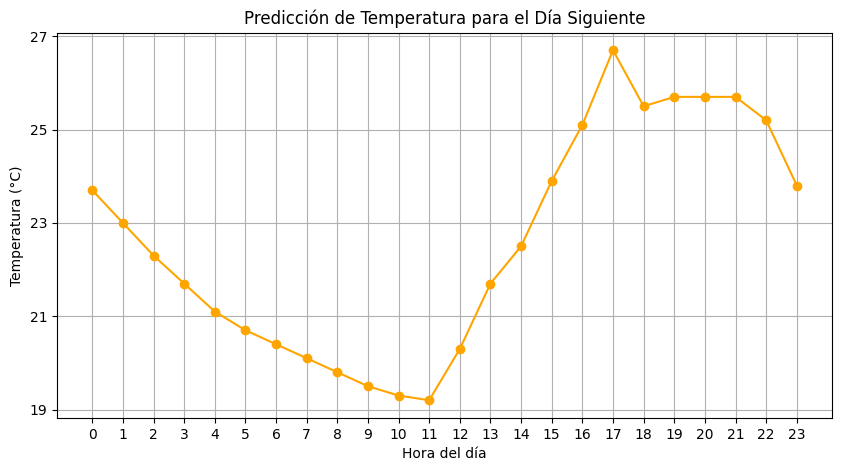

In [7]:
pred_dia_siguiente_lr_model['Hora'] = pred_dia_siguiente_lr_model['Fecha'].dt.hour

plt.figure(figsize=(10,5))
plt.plot(pred_dia_siguiente_lr_model['Hora'], pred_dia_siguiente_lr_model['Predicción_Temperatura'], marker='o', color='orange')
plt.xticks(range(0,24))
# Eje y de 2 en 2
y_min = int(np.floor(pred_dia_siguiente_lr_model['Predicción_Temperatura'].min()))
y_max = int(np.ceil(pred_dia_siguiente_lr_model['Predicción_Temperatura'].max()))
plt.yticks(np.arange(y_min, y_max+1, 2))
plt.xlabel("Hora del día")
plt.ylabel("Temperatura (°C)")
plt.title("Predicción de Temperatura para el Día Siguiente")
plt.grid(True)
plt.show()



# ***MODELO REGRESIÓN LINEAL PM2.5***

In [110]:
# Definir features y target
features_PM_25 = ["uv_index","humidity","bound_lay_hei"]
features_contam = ["no2", "aero_op", "co","so2","ch4"]
features_estacionalidad = ["sin_hour", "cos_hour", "sin_day", "cos_day"]
target_pm25 = "pm2_5"

# Dataset
df_pm = df.copy()
df_pm["date"] = pd.to_datetime(df_pm["date"])
df_pm = df_pm.sort_values("date").reset_index(drop=True)

# Variables de estacionalidad (cíclicas)
df_pm["hour"] = df_pm["date"].dt.hour
df_pm["day_of_year"] = df_pm["date"].dt.dayofyear
df_pm["sin_hour"] = np.sin(2 * np.pi * df_pm["hour"] / 24)
df_pm["cos_hour"] = np.cos(2 * np.pi * df_pm["hour"] / 24)
df_pm["sin_day"] = np.sin(2 * np.pi * df_pm["day_of_year"] / 365)
df_pm["cos_day"] = np.cos(2 * np.pi * df_pm["day_of_year"] / 365)

# Añadir pred_temp (temperatura predicha)
df_pm["pred_temp"] = np.nan
df_pm.loc[df_pm.index[-len(y_pred):], "pred_temp"] = y_pred  # alinear por fechas si es necesario

# Features finales
X_cols = features_PM_25 + features_contam + ["pred_temp"] + features_estacionalidad

# Quitar filas con NAs
df_pm = df_pm.dropna(subset=X_cols + [target_pm25])

X_PM = df_pm[X_cols]
y_PM = df_pm[target_pm25]

# Split train/test
X_train_pm, X_test_pm, y_train_pm, y_test_pm = train_test_split(X_PM, y_PM, test_size=0.2, shuffle=False)
dates_test_pm = df_pm["date"].iloc[-len(y_test_pm):]

Regresión Lineal
R² CV promedio: 0.8044
RMSE CV promedio: 3.5830
MAE CV promedio: 2.7145
R² Test: 0.7336
RMSE Test: 4.1472
MAE Test: 3.1443


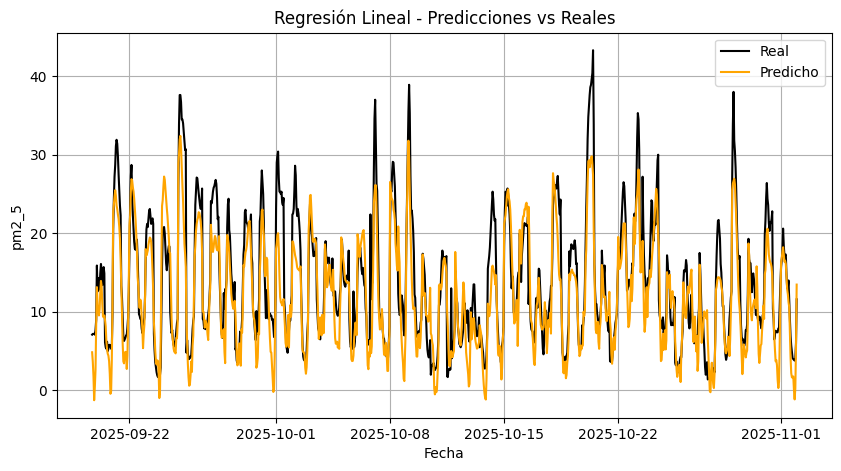

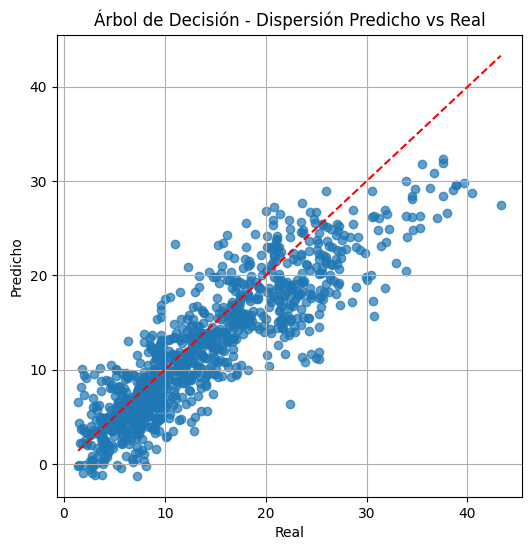

                       Fecha Predicción_PM2.5
0  2025-11-02 00:00:00+00:00             16.3
1  2025-11-02 01:00:00+00:00             16.8
2  2025-11-02 02:00:00+00:00             17.6
3  2025-11-02 03:00:00+00:00             18.2
4  2025-11-02 04:00:00+00:00             17.3
5  2025-11-02 05:00:00+00:00             16.4
6  2025-11-02 06:00:00+00:00             16.5
7  2025-11-02 07:00:00+00:00             16.1
8  2025-11-02 08:00:00+00:00             14.6
9  2025-11-02 09:00:00+00:00             12.9
10 2025-11-02 10:00:00+00:00             12.3
11 2025-11-02 11:00:00+00:00             11.2
12 2025-11-02 12:00:00+00:00             10.6
13 2025-11-02 13:00:00+00:00              7.5
14 2025-11-02 14:00:00+00:00              4.2
15 2025-11-02 15:00:00+00:00              2.2
16 2025-11-02 16:00:00+00:00              1.7
17 2025-11-02 17:00:00+00:00              1.7
18 2025-11-02 18:00:00+00:00              1.8
19 2025-11-02 19:00:00+00:00              0.0
20 2025-11-02 20:00:00+00:00      

/tmp/ipython-input-2780294188.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [111]:

# Pipeline con scaler
modelo_lr_pm = LinearRegression()
pipeline_lr = Pipeline([('scaler', StandardScaler()), ('model', modelo_lr_pm)])

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_validate(
    pipeline_lr, X_train_pm, y_train_pm, cv=kf,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error')
)

# Entrenar y predecir
pipeline_lr.fit(X_train_pm, y_train_pm)
y_pred_lr = pipeline_lr.predict(X_test_pm)

# Métricas
r2_lr = r2_score(y_test_pm, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_pm, y_pred_lr))
mae_lr = mean_absolute_error(y_test_pm, y_pred_lr)

print("Regresión Lineal")
print(f"R² CV promedio: {np.mean(scores_lr['test_r2']):.4f}")
print(f"RMSE CV promedio: {np.mean(np.sqrt(-scores_lr['test_neg_mean_squared_error'])):.4f}")
print(f"MAE CV promedio: {np.mean(-scores_lr['test_neg_mean_absolute_error']):.4f}")
print(f"R² Test: {r2_lr:.4f}")
print(f"RMSE Test: {rmse_lr:.4f}")
print(f"MAE Test: {mae_lr:.4f}")

# Gráficos
plt.figure(figsize=(10,5))
plt.plot(dates_test_pm, y_test_pm.values, label="Real", color='black')
plt.plot(dates_test_pm, y_pred_lr, label="Predicho", color='orange')
plt.title("Regresión Lineal - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target_pm25)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test_pm, y_pred_lr, alpha=0.7)
plt.plot([y_test_pm.min(), y_test_pm.max()], [y_test_pm.min(), y_test_pm.max()], 'r--')
plt.title("Árbol de Decisión - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

ultimo_dia_PM = df_pm[X_cols].iloc[-24:]  # solo las features usadas en entrenamiento
predicciones_siguientes = pipeline_lr.predict(ultimo_dia_PM)

ultimo_dia_completo = df_pm["date"].iloc[-1].normalize()
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_modelo_lr_pm = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_PM2.5": np.round(predicciones_siguientes, 1)
})
print(pred_dia_siguiente_modelo_lr_pm.to_string(formatters={'Predicción_PM2.5': '{:.1f}'.format}))


In [ ]:
# Guardar predicciones del día siguiente en CSV
pred_dia_siguiente_lr_model.to_csv("prediccion_dia_siguiente4.csv", index=False)
print("Archivo CSV guardado como 'prediccion_dia_siguiente4.csv'")


Archivo CSV guardado como 'prediccion_dia_siguiente4.csv'


# ***MODELO DECISION TREE REGRESSOR TEMPERATURA***

Resultados Árbol de Decisión
R² CV promedio: 0.9828
RMSE CV promedio: 0.4449
MAE CV promedio: 0.3321
R² Test: 0.8731
RMSE Test: 1.0830
MAE Test: 0.8804


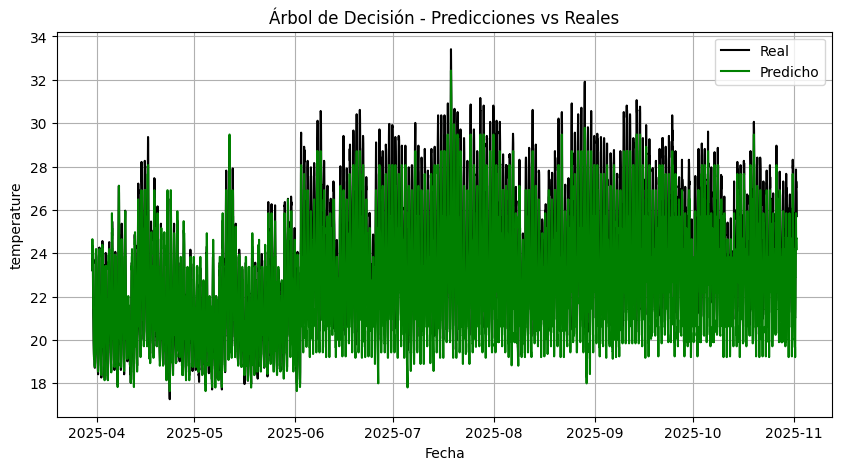

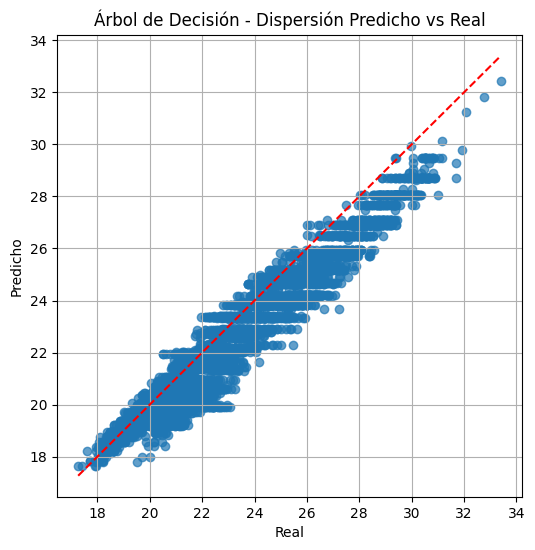

                       Fecha Predicción_Temperatura
0  2025-11-02 00:00:00+00:00                   24.2
1  2025-11-02 01:00:00+00:00                   23.8
2  2025-11-02 02:00:00+00:00                   23.4
3  2025-11-02 03:00:00+00:00                   21.6
4  2025-11-02 04:00:00+00:00                   20.0
5  2025-11-02 05:00:00+00:00                   20.0
6  2025-11-02 06:00:00+00:00                   20.0
7  2025-11-02 07:00:00+00:00                   19.7
8  2025-11-02 08:00:00+00:00                   19.7
9  2025-11-02 09:00:00+00:00                   19.7
10 2025-11-02 10:00:00+00:00                   19.7
11 2025-11-02 11:00:00+00:00                   19.2
12 2025-11-02 12:00:00+00:00                   20.4
13 2025-11-02 13:00:00+00:00                   22.0
14 2025-11-02 14:00:00+00:00                   22.9
15 2025-11-02 15:00:00+00:00                   22.9
16 2025-11-02 16:00:00+00:00                   24.6
17 2025-11-02 17:00:00+00:00                   25.8
18 2025-11-0

/tmp/ipython-input-2633705413.py:55: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [30]:

dt_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

pipeline = Pipeline([('scaler', scaler), ('model', dt_model)])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipeline, X_train, y_train, cv=kf,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'),
    return_train_score=False)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Resultados Árbol de Decisión")
print(f"R² CV promedio: {np.mean(scores['test_r2']):.4f}")
print(f"RMSE CV promedio: {np.mean(np.sqrt(-scores['test_neg_mean_squared_error'])):.4f}")
print(f"MAE CV promedio: {np.mean(-scores['test_neg_mean_absolute_error']):.4f}")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test.values, label="Real", color='black')
plt.plot(dates_test, y_pred, label="Predicho", color='green')
plt.title("Árbol de Decisión - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Árbol de Decisión - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

ultimo_dia = df[final_features].iloc[-24:]
predicciones_siguientes = pipeline.predict(ultimo_dia)

# Obtener el último día completo del dataset desde la columna 'date'
ultimo_dia_completo = df["date"].iloc[-1].normalize()  # Ej: 2025-11-01 00:00:00
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_dt_model = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_Temperatura": np.round(predicciones_siguientes, 1)
})
print(pred_dia_siguiente_dt_model.to_string(formatters={'Predicción_Temperatura': '{:.1f}'.format}))

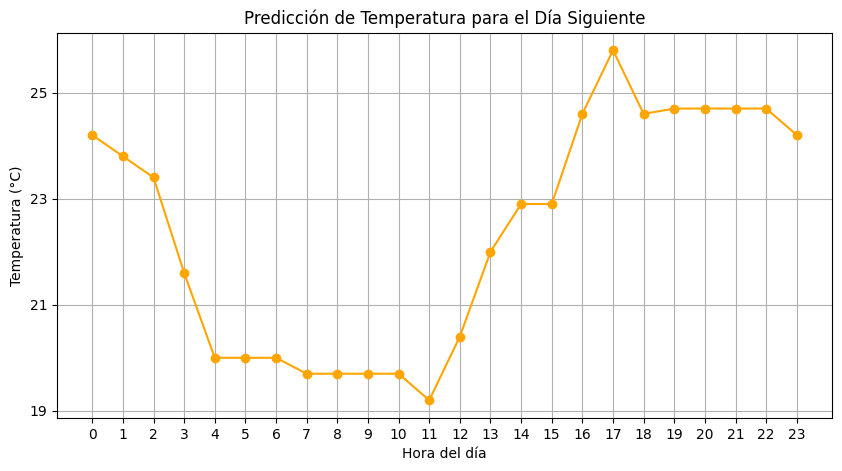

In [31]:
pred_dia_siguiente_dt_model['Hora'] = pred_dia_siguiente_dt_model['Fecha'].dt.hour

plt.figure(figsize=(10,5))
plt.plot(pred_dia_siguiente_dt_model['Hora'], pred_dia_siguiente_dt_model['Predicción_Temperatura'], marker='o', color='orange')
plt.xticks(range(0,24))
# Eje y de 2 en 2
y_min = int(np.floor(pred_dia_siguiente_dt_model['Predicción_Temperatura'].min()))
y_max = int(np.ceil(pred_dia_siguiente_dt_model['Predicción_Temperatura'].max()))
plt.yticks(np.arange(y_min, y_max+1, 2))
plt.xlabel("Hora del día")
plt.ylabel("Temperatura (°C)")
plt.title("Predicción de Temperatura para el Día Siguiente")
plt.grid(True)
plt.show()



# ***DECISION TREE REGRESSOR PM2.5***

Resultados Árbol de Decisión
R² CV promedio: 0.7577
RMSE CV promedio: 3.9862
MAE CV promedio: 2.8504
R² Test: 0.7314
RMSE Test: 4.1637
MAE Test: 3.0450


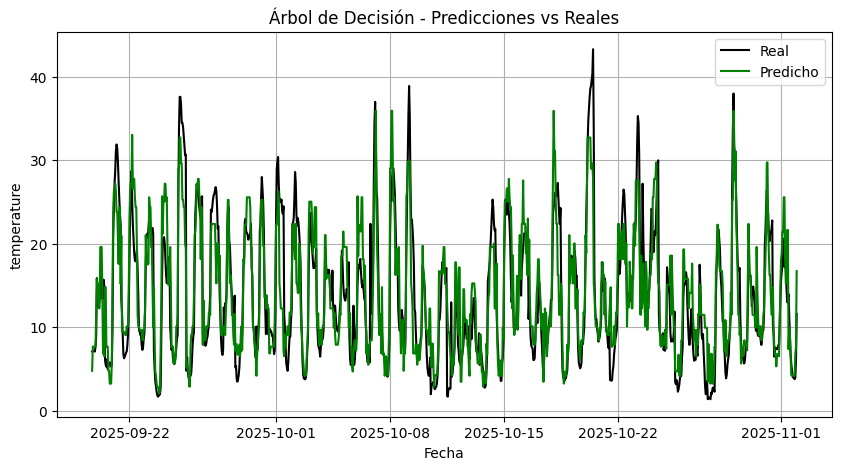

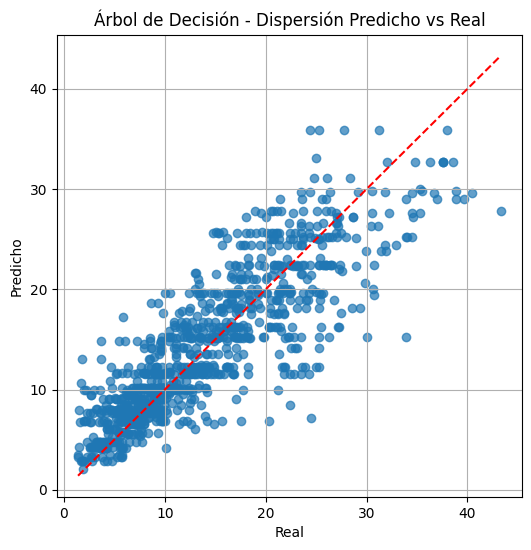

                       Fecha Predicción_PM2.5
0  2025-11-02 00:00:00+00:00             33.1
1  2025-11-02 01:00:00+00:00             33.1
2  2025-11-02 02:00:00+00:00             33.1
3  2025-11-02 03:00:00+00:00             33.1
4  2025-11-02 04:00:00+00:00             33.1
5  2025-11-02 05:00:00+00:00             33.1
6  2025-11-02 06:00:00+00:00             33.1
7  2025-11-02 07:00:00+00:00             33.1
8  2025-11-02 08:00:00+00:00             33.1
9  2025-11-02 09:00:00+00:00             33.1
10 2025-11-02 10:00:00+00:00             33.1
11 2025-11-02 11:00:00+00:00             33.1
12 2025-11-02 12:00:00+00:00             33.1
13 2025-11-02 13:00:00+00:00             33.1
14 2025-11-02 14:00:00+00:00             33.1
15 2025-11-02 15:00:00+00:00             26.6
16 2025-11-02 16:00:00+00:00             18.2
17 2025-11-02 17:00:00+00:00             25.6
18 2025-11-02 18:00:00+00:00             27.8
19 2025-11-02 19:00:00+00:00             15.3
20 2025-11-02 20:00:00+00:00      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipython-input-1241524113.py:54: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [115]:

dt_model_pm = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

pipeline_dt_pm = Pipeline([('scaler', scaler), ('model', dt_model_pm)])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipeline_dt_pm, X_train_pm, y_train_pm, cv=kf,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'),
    return_train_score=False)

pipeline_dt_pm.fit(X_train_pm, y_train_pm)
y_pred = pipeline_dt_pm.predict(X_test_pm)

r2 = r2_score(y_test_pm, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_pm, y_pred))
mae = mean_absolute_error(y_test_pm, y_pred)

print("Resultados Árbol de Decisión")
print(f"R² CV promedio: {np.mean(scores['test_r2']):.4f}")
print(f"RMSE CV promedio: {np.mean(np.sqrt(-scores['test_neg_mean_squared_error'])):.4f}")
print(f"MAE CV promedio: {np.mean(-scores['test_neg_mean_absolute_error']):.4f}")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

plt.figure(figsize=(10,5))
plt.plot(dates_test_pm, y_test_pm.values, label="Real", color='black')
plt.plot(dates_test_pm, y_pred, label="Predicho", color='green')
plt.title("Árbol de Decisión - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test_pm, y_pred, alpha=0.7)
plt.plot([y_test_pm.min(), y_test_pm.max()], [y_test_pm.min(), y_test_pm.max()], 'r--')
plt.title("Árbol de Decisión - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

ultimo_dia_PM = df_pm[X_cols].iloc[-24:]  # solo las features usadas en entrenamiento
predicciones_siguientes = pipeline_dt_pm.predict(ultimo_dia_PM)

ultimo_dia_completo = df_pm["date"].iloc[-1].normalize()
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_modelo_lr_pm = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_PM2.5": np.round(predicciones_siguientes, 1)
})
print(pred_dia_siguiente_modelo_lr_pm.to_string(formatters={'Predicción_PM2.5': '{:.1f}'.format}))


# ***MODELO RANDOM FOREST REGRESSOR TEMPERATURA***

Resultados Random Forest
R² CV promedio: 0.9854
RMSE CV promedio: 0.4095
MAE CV promedio: 0.2947
R² Test: 0.9046
RMSE Test: 0.9393
MAE Test: 0.7669


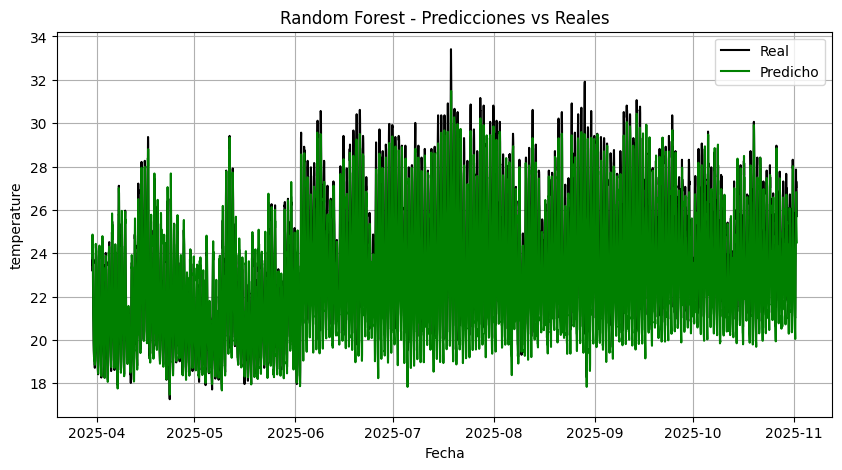

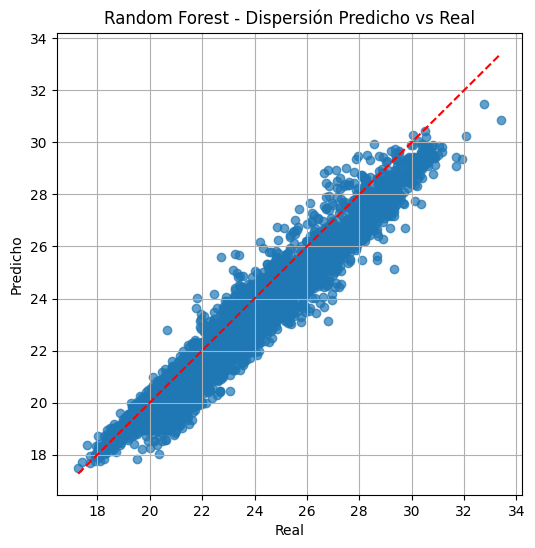

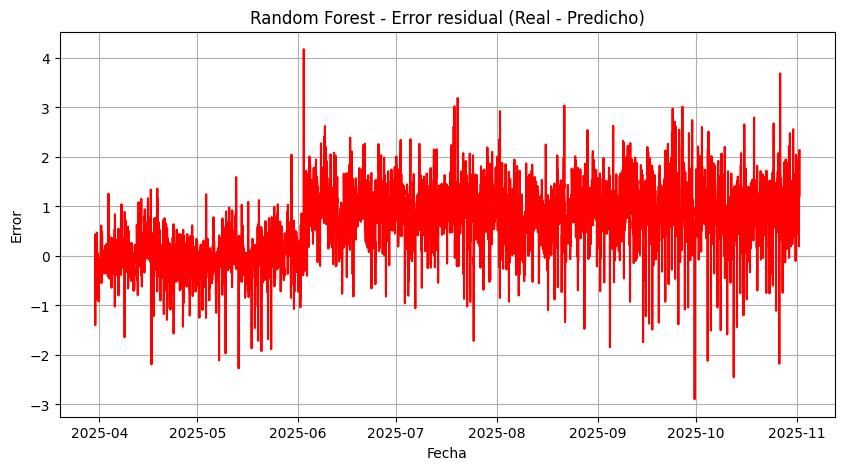

                       Fecha Predicción_Temperatura
0  2025-11-02 00:00:00+00:00                   23.9
1  2025-11-02 01:00:00+00:00                   23.8
2  2025-11-02 02:00:00+00:00                   22.8
3  2025-11-02 03:00:00+00:00                   22.4
4  2025-11-02 04:00:00+00:00                   21.9
5  2025-11-02 05:00:00+00:00                   21.5
6  2025-11-02 06:00:00+00:00                   21.3
7  2025-11-02 07:00:00+00:00                   21.2
8  2025-11-02 08:00:00+00:00                   20.8
9  2025-11-02 09:00:00+00:00                   20.5
10 2025-11-02 10:00:00+00:00                   20.4
11 2025-11-02 11:00:00+00:00                   20.0
12 2025-11-02 12:00:00+00:00                   20.0
13 2025-11-02 13:00:00+00:00                   21.8
14 2025-11-02 14:00:00+00:00                   23.3
15 2025-11-02 15:00:00+00:00                   23.9
16 2025-11-02 16:00:00+00:00                   25.3
17 2025-11-02 17:00:00+00:00                   25.9
18 2025-11-0

/tmp/ipython-input-2453112289.py:72: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
dates_test = df["date"].iloc[-len(y_test):]

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
scaler = StandardScaler()
pipeline = Pipeline([('scaler', scaler), ('model', rf_model)])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipeline, X_train, y_train, cv=kf,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'),
    return_train_score=False
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Resultados Random Forest")
print(f"R² CV promedio: {np.mean(scores['test_r2']):.4f}")
print(f"RMSE CV promedio: {np.mean(np.sqrt(-scores['test_neg_mean_squared_error'])):.4f}")
print(f"MAE CV promedio: {np.mean(-scores['test_neg_mean_absolute_error']):.4f}")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test.values, label="Real", color='black')
plt.plot(dates_test, y_pred, label="Predicho", color='green')
plt.title("Random Forest - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test.values - y_pred, color='red')
plt.title("Random Forest - Error residual (Real - Predicho)")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# Predicción del día siguiente (24 horas)
ultimo_dia = df[final_features].iloc[-24:]
predicciones_siguientes = pipeline.predict(ultimo_dia)

# Obtener el último día completo del dataset desde la columna 'date'
ultimo_dia_completo = df["date"].iloc[-1].normalize()  # Ej: 2025-11-01 00:00:00
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_rf_model = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_Temperatura": np.round(predicciones_siguientes, 1)
})
print(pred_dia_siguiente_rf_model.to_string(formatters={'Predicción_Temperatura': '{:.1f}'.format}))

In [ ]:
pred_dia_siguiente_rf_model['Hora'] = pred_dia_siguiente_rf_model['Fecha'].dt.hour

plt.figure(figsize=(10,5))
plt.plot(pred_dia_siguiente_rf_model['Hora'], pred_dia_siguiente_rf_model['Predicción_Temperatura'], marker='o', color='orange')
plt.xticks(range(0,24))
# Eje y de 2 en 2
y_min = int(np.floor(pred_dia_siguiente_rf_model['Predicción_Temperatura'].min()))
y_max = int(np.ceil(pred_dia_siguiente_rf_model['Predicción_Temperatura'].max()))
plt.yticks(np.arange(y_min, y_max+1, 2))
plt.xlabel("Hora del día")
plt.ylabel("Temperatura (°C)")
plt.title("Predicción de Temperatura para el Día Siguiente")
plt.grid(True)
plt.show()


# ***MODELO RANDOM FOREST REGRESSOR PM2.5***

Resultados Random Forest PM2.5
R² CV promedio: 0.8394
RMSE CV promedio: 3.2461
MAE CV promedio: 2.3412
R² Test: 0.7775
RMSE Test: 3.7896
MAE Test: 2.8162


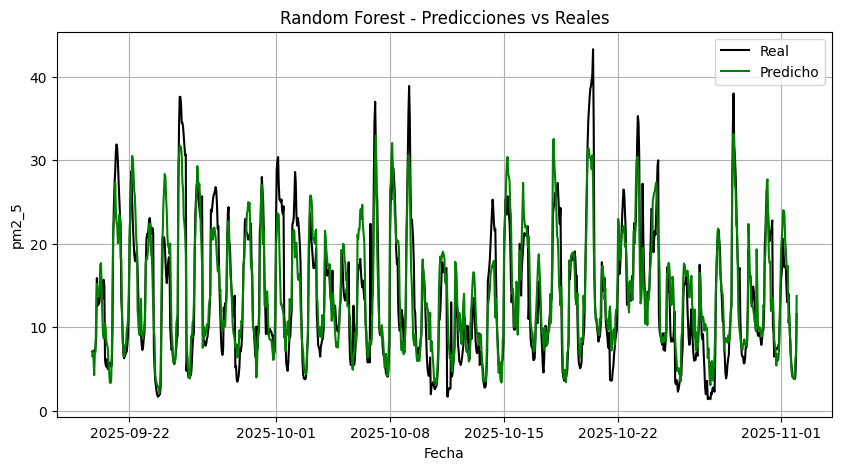

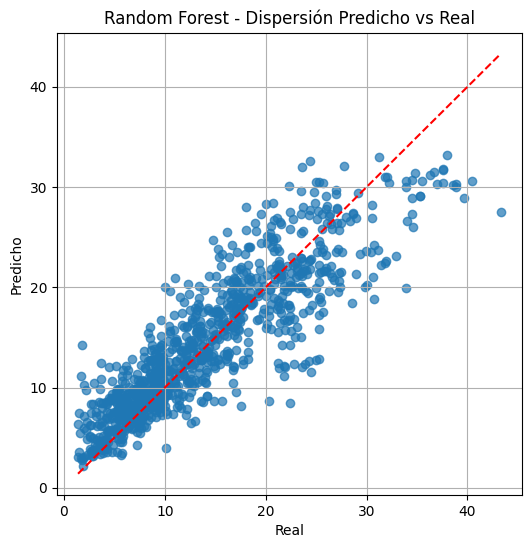

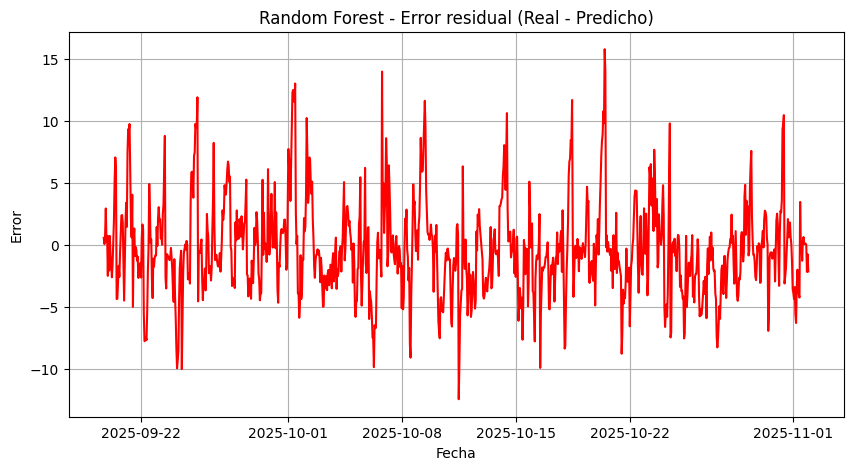

                       Fecha Predicción_PM2.5
0  2025-11-02 00:00:00+00:00             31.2
1  2025-11-02 01:00:00+00:00             31.2
2  2025-11-02 02:00:00+00:00             31.2
3  2025-11-02 03:00:00+00:00             31.2
4  2025-11-02 04:00:00+00:00             31.2
5  2025-11-02 05:00:00+00:00             31.2
6  2025-11-02 06:00:00+00:00             31.2
7  2025-11-02 07:00:00+00:00             31.2
8  2025-11-02 08:00:00+00:00             30.9
9  2025-11-02 09:00:00+00:00             30.9
10 2025-11-02 10:00:00+00:00             30.9
11 2025-11-02 11:00:00+00:00             30.9
12 2025-11-02 12:00:00+00:00             30.9
13 2025-11-02 13:00:00+00:00             31.0
14 2025-11-02 14:00:00+00:00             31.0
15 2025-11-02 15:00:00+00:00             29.7
16 2025-11-02 16:00:00+00:00             20.4
17 2025-11-02 17:00:00+00:00             22.3
18 2025-11-02 18:00:00+00:00             25.5
19 2025-11-02 19:00:00+00:00             19.2
20 2025-11-02 20:00:00+00:00      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipython-input-3195607959.py:71: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [116]:
rf_model_pm = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
scaler = StandardScaler()
pipeline_rf_pm = Pipeline([('scaler', scaler), ('model', rf_model_pm)])

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipeline_rf_pm, X_train_pm, y_train_pm, cv=kf,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'),
    return_train_score=False
)

# Entrenar y predecir
pipeline_rf_pm.fit(X_train_pm, y_train_pm)
y_pred_pm = pipeline_rf_pm.predict(X_test_pm)

# Métricas
r2 = r2_score(y_test_pm, y_pred_pm)
rmse = np.sqrt(mean_squared_error(y_test_pm, y_pred_pm))
mae = mean_absolute_error(y_test_pm, y_pred_pm)

print("Resultados Random Forest PM2.5")
print(f"R² CV promedio: {np.mean(scores['test_r2']):.4f}")
print(f"RMSE CV promedio: {np.mean(np.sqrt(-scores['test_neg_mean_squared_error'])):.4f}")
print(f"MAE CV promedio: {np.mean(-scores['test_neg_mean_absolute_error']):.4f}")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

# Gráficos
plt.figure(figsize=(10,5))
plt.plot(dates_test_pm, y_test_pm.values, label="Real", color='black')
plt.plot(dates_test_pm, y_pred_pm, label="Predicho", color='green')
plt.title("Random Forest - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target_pm25)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test_pm, y_pred_pm, alpha=0.7)
plt.plot([y_test_pm.min(), y_test_pm.max()], [y_test_pm.min(), y_test_pm.max()], 'r--')
plt.title("Random Forest - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(dates_test_pm, y_test_pm.values - y_pred_pm, color='red')
plt.title("Random Forest - Error residual (Real - Predicho)")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# Predicción del día siguiente (24 horas)
ultimo_dia_PM = df_pm[X_cols].iloc[-24:]  # usar solo features de entrenamiento
predicciones_siguientes = pipeline_rf_pm.predict(ultimo_dia_PM)

# Fechas del día siguiente
ultimo_dia_completo = df_pm["date"].iloc[-1].normalize()
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_rf_pm = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_PM2.5": np.round(predicciones_siguientes, 1)
})
print(pred_dia_siguiente_rf_pm.to_string(formatters={'Predicción_PM2.5': '{:.1f}'.format}))


# ***MODELO SUPPORT VECTOR  REGRESSOR TEMPERATURA***

Resultados SVM Regressor
R² CV promedio: 0.9944
RMSE CV promedio: 0.2547
MAE CV promedio: 0.1896
R² Test: 0.9094
RMSE Test: 0.9153
MAE Test: 0.7619


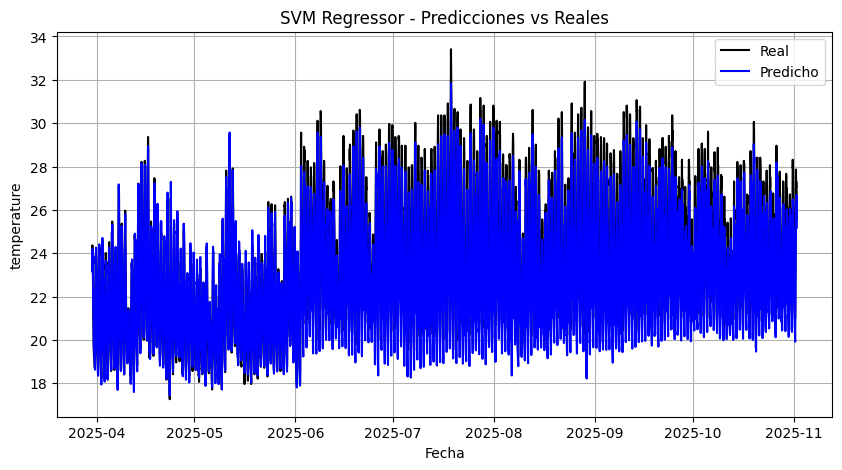

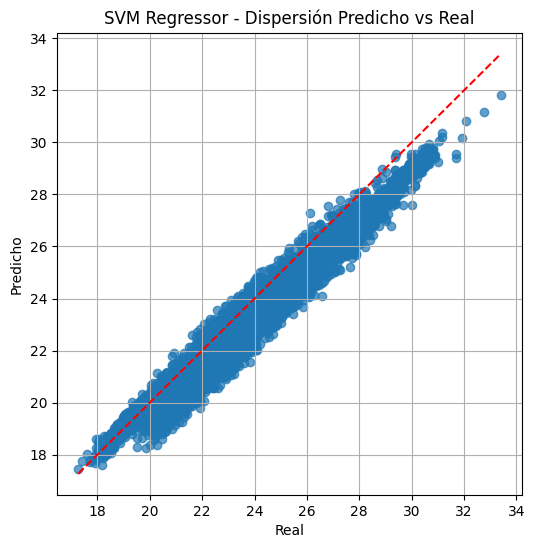

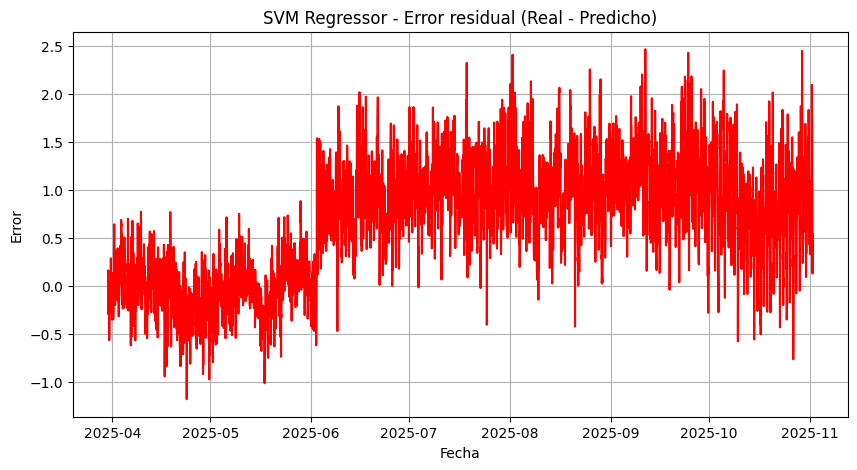

                       Fecha Predicción_Temperatura
0  2025-11-02 00:00:00+00:00                   25.1
1  2025-11-02 01:00:00+00:00                   24.1
2  2025-11-02 02:00:00+00:00                   23.1
3  2025-11-02 03:00:00+00:00                   22.7
4  2025-11-02 04:00:00+00:00                   22.1
5  2025-11-02 05:00:00+00:00                   21.5
6  2025-11-02 06:00:00+00:00                   21.1
7  2025-11-02 07:00:00+00:00                   20.9
8  2025-11-02 08:00:00+00:00                   20.6
9  2025-11-02 09:00:00+00:00                   20.4
10 2025-11-02 10:00:00+00:00                   20.2
11 2025-11-02 11:00:00+00:00                   19.9
12 2025-11-02 12:00:00+00:00                   20.9
13 2025-11-02 13:00:00+00:00                   22.3
14 2025-11-02 14:00:00+00:00                   23.2
15 2025-11-02 15:00:00+00:00                   24.3
16 2025-11-02 16:00:00+00:00                   25.1
17 2025-11-02 17:00:00+00:00                   25.8
18 2025-11-0

/tmp/ipython-input-1702182975.py:67: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [38]:
from sklearn.svm import SVR

svm_model = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1,
    gamma='scale'
)
scaler = StandardScaler()
pipeline = Pipeline([('scaler', scaler), ('model', svm_model)])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipeline, X_train, y_train, cv=kf,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'),
    return_train_score=False
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Resultados SVM Regressor")
print(f"R² CV promedio: {np.mean(scores['test_r2']):.4f}")
print(f"RMSE CV promedio: {np.mean(np.sqrt(-scores['test_neg_mean_squared_error'])):.4f}")
print(f"MAE CV promedio: {np.mean(-scores['test_neg_mean_absolute_error']):.4f}")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test.values, label="Real", color='black')
plt.plot(dates_test, y_pred, label="Predicho", color='blue')
plt.title("SVM Regressor - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("SVM Regressor - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test.values - y_pred, color='red')
plt.title("SVM Regressor - Error residual (Real - Predicho)")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.grid(True)
plt.show()

ultimo_dia = df[final_features].iloc[-24:]
predicciones_siguientes = pipeline.predict(ultimo_dia)

# Obtener el último día completo del dataset desde la columna 'date'
ultimo_dia_completo = df["date"].iloc[-1].normalize()  # Ej: 2025-11-01 00:00:00
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_svm_model = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_Temperatura": np.round(predicciones_siguientes, 1)
})
print(pred_dia_siguiente_svm_model.to_string(formatters={'Predicción_Temperatura': '{:.1f}'.format}))


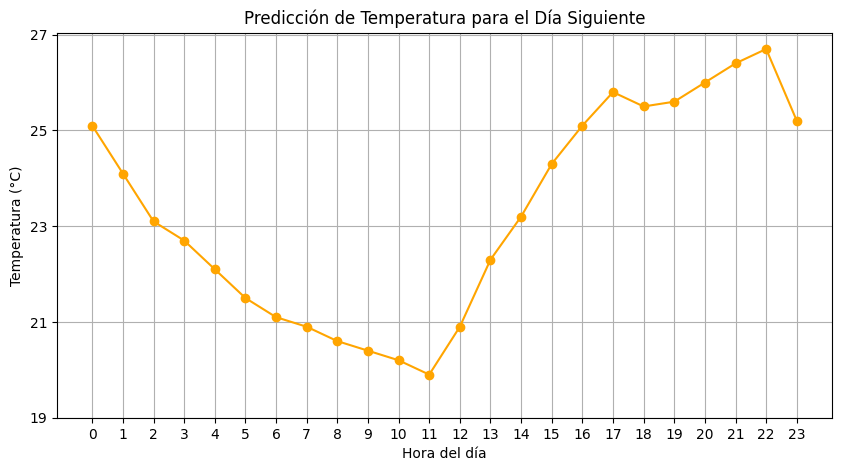

In [40]:
pred_dia_siguiente_svm_model['Hora'] = pred_dia_siguiente_svm_model['Fecha'].dt.hour

plt.figure(figsize=(10,5))
plt.plot(pred_dia_siguiente_svm_model['Hora'], pred_dia_siguiente_svm_model['Predicción_Temperatura'], marker='o', color='orange')
plt.xticks(range(0,24))
# Eje y de 2 en 2
y_min = int(np.floor(pred_dia_siguiente_svm_model['Predicción_Temperatura'].min()))
y_max = int(np.ceil(pred_dia_siguiente_svm_model['Predicción_Temperatura'].max()))
plt.yticks(np.arange(y_min, y_max+1, 2))
plt.xlabel("Hora del día")
plt.ylabel("Temperatura (°C)")
plt.title("Predicción de Temperatura para el Día Siguiente")
plt.grid(True)
plt.show()


# ***MODELO SUPPORT VECTOR  REGRESSOR PM2.5***

Resultados SVM Regressor PM2.5
R² CV promedio: 0.8482
RMSE CV promedio: 3.1551
MAE CV promedio: 2.2067
R² Test: 0.7499
RMSE Test: 4.0183
MAE Test: 2.9702


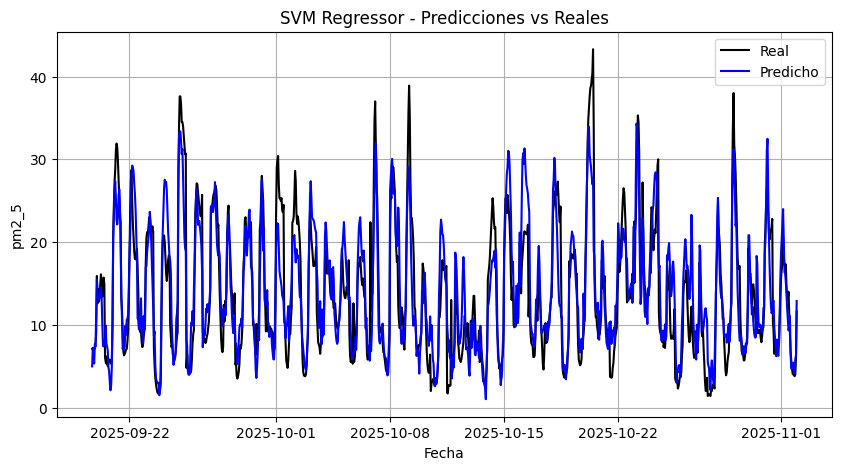

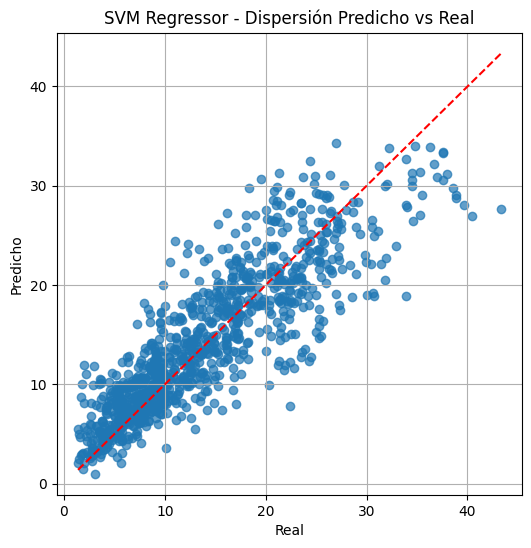

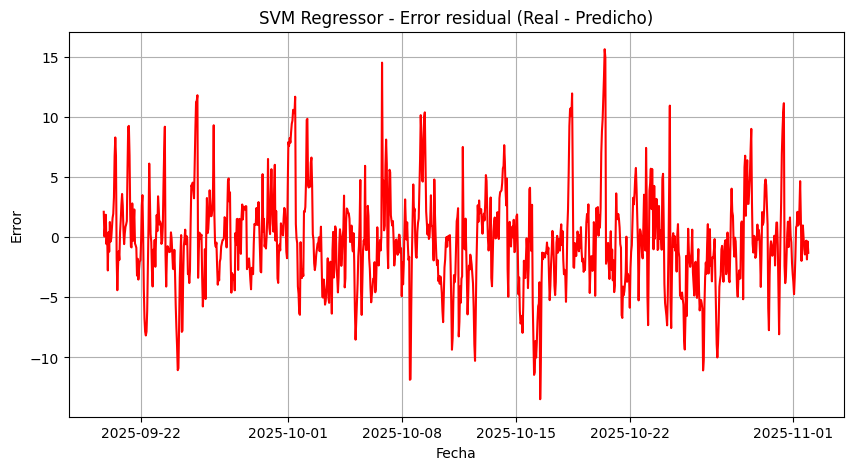

                       Fecha Predicción_PM2.5
0  2025-11-02 00:00:00+00:00             17.3
1  2025-11-02 01:00:00+00:00             17.3
2  2025-11-02 02:00:00+00:00             17.3
3  2025-11-02 03:00:00+00:00             17.3
4  2025-11-02 04:00:00+00:00             17.3
5  2025-11-02 05:00:00+00:00             17.3
6  2025-11-02 06:00:00+00:00             17.3
7  2025-11-02 07:00:00+00:00             17.3
8  2025-11-02 08:00:00+00:00             17.3
9  2025-11-02 09:00:00+00:00             17.3
10 2025-11-02 10:00:00+00:00             17.3
11 2025-11-02 11:00:00+00:00             17.3
12 2025-11-02 12:00:00+00:00             17.3
13 2025-11-02 13:00:00+00:00             17.3
14 2025-11-02 14:00:00+00:00             17.3
15 2025-11-02 15:00:00+00:00             17.3
16 2025-11-02 16:00:00+00:00             17.3
17 2025-11-02 17:00:00+00:00             17.3
18 2025-11-02 18:00:00+00:00             17.3
19 2025-11-02 19:00:00+00:00             17.3
20 2025-11-02 20:00:00+00:00      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/tmp/ipython-input-3783682515.py:73: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [117]:
from sklearn.svm import SVR

# Modelo SVM para PM2.5
svm_pm_model = SVR(
    kernel='rbf',
    C=100,
    epsilon=0.1,
    gamma='scale'
)
scaler = StandardScaler()
pipeline_svm_pm = Pipeline([('scaler', scaler), ('model', svm_pm_model)])

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    pipeline_svm_pm, X_train_pm, y_train_pm, cv=kf,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'),
    return_train_score=False
)

# Entrenar y predecir
pipeline_svm_pm.fit(X_train_pm, y_train_pm)
y_pred_pm = pipeline_svm_pm.predict(X_test_pm)

# Métricas
r2 = r2_score(y_test_pm, y_pred_pm)
rmse = np.sqrt(mean_squared_error(y_test_pm, y_pred_pm))
mae = mean_absolute_error(y_test_pm, y_pred_pm)

print("Resultados SVM Regressor PM2.5")
print(f"R² CV promedio: {np.mean(scores['test_r2']):.4f}")
print(f"RMSE CV promedio: {np.mean(np.sqrt(-scores['test_neg_mean_squared_error'])):.4f}")
print(f"MAE CV promedio: {np.mean(-scores['test_neg_mean_absolute_error']):.4f}")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

# Gráficos
plt.figure(figsize=(10,5))
plt.plot(dates_test_pm, y_test_pm.values, label="Real", color='black')
plt.plot(dates_test_pm, y_pred_pm, label="Predicho", color='blue')
plt.title("SVM Regressor - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target_pm25)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test_pm, y_pred_pm, alpha=0.7)
plt.plot([y_test_pm.min(), y_test_pm.max()], [y_test_pm.min(), y_test_pm.max()], 'r--')
plt.title("SVM Regressor - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(dates_test_pm, y_test_pm.values - y_pred_pm, color='red')
plt.title("SVM Regressor - Error residual (Real - Predicho)")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# Predicción del día siguiente (24 horas)
ultimo_dia_PM = df_pm[X_cols].iloc[-24:]  # usar solo features de entrenamiento
predicciones_siguientes = pipeline_svm_pm.predict(ultimo_dia_PM)

# Fechas del día siguiente
ultimo_dia_completo = df_pm["date"].iloc[-1].normalize()
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_svm_pm = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_PM2.5": np.round(predicciones_siguientes, 1)
})
print(pred_dia_siguiente_svm_pm.to_string(formatters={'Predicción_PM2.5': '{:.1f}'.format}))



# ***DEEP LEARNING REGRESSOR TEMPERATURE***

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,601 (37.50 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
Epoch 2/200
Epoch 3/200
Epoch 4/200
Epoch 5/200
Epoch 6/200
Epoch 7/200
Epoch 8/200
Epoch 9/200
Epoch 10/200
Epoch 11/200
Epoch 12/200
Epoch 13/200
Epoch 14/200
Epoch 15/200
Epoch 16/200
Epoch 17/200
Epoch 18/200
Epoch 19/200
Epoch 20/200
Epoch 21/200
Epoch 22/200
Epoch 23/200
Epoch 24/200
Epoch 25/200
Epoch 26/200
Epoch 27/200
Epoch 28/200
Epoch 29/200
Epoch 30/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Deep Learning Regressor - Test resultados
R² Test: 0.9133
RMSE Test: 0.8954
MAE Test: 0.7420


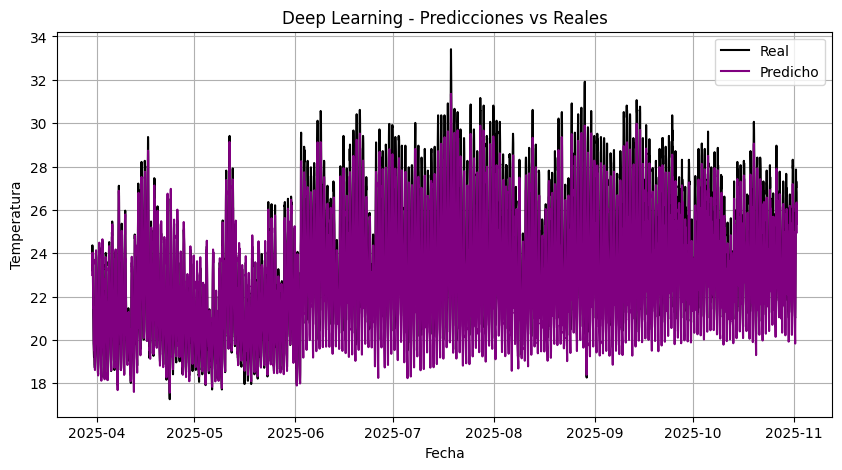

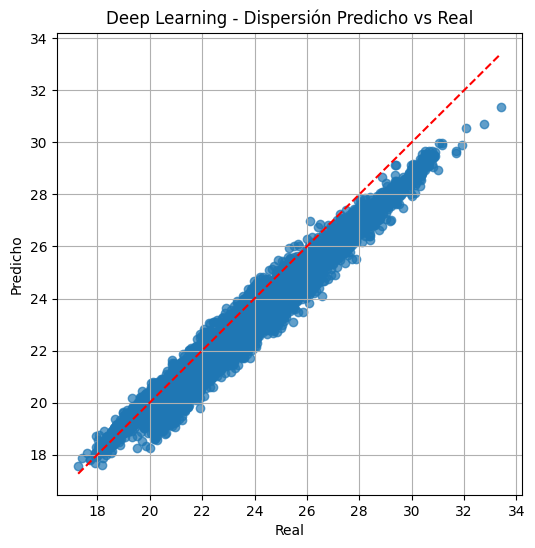

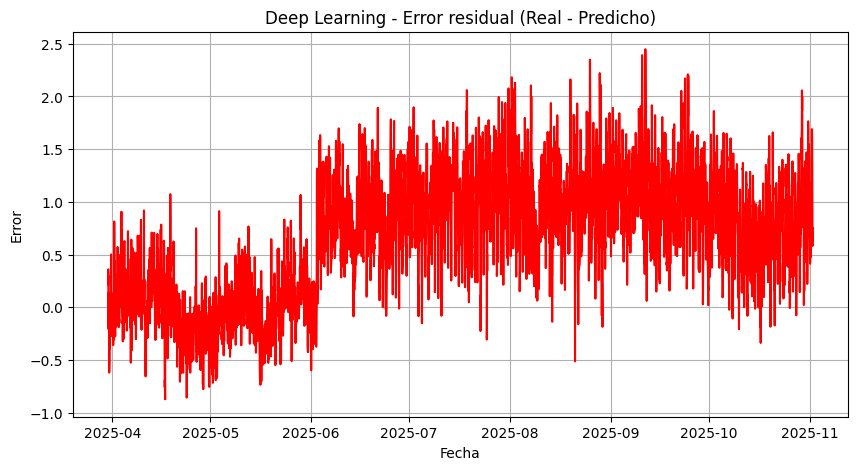

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
                       Fecha  Predicción_Temperatura
0  2025-11-02 00:00:00+00:00               25.000000
1  2025-11-02 01:00:00+00:00               23.900000
2  2025-11-02 02:00:00+00:00               23.100000
3  2025-11-02 03:00:00+00:00               22.600000
4  2025-11-02 04:00:00+00:00               22.000000
5  2025-11-02 05:00:00+00:00               21.500000
6  2025-11-02 06:00:00+00:00               21.400000
7  2025-11-02 07:00:00+00:00               21.100000
8  2025-11-02 08:00:00+00:00               20.700001
9  2025-11-02 09:00:00+00:00               20.500000
10 2025-11-02 10:00:00+00:00               20.200001
11 2025-11-02 11:00:00+00:00               19.799999
12 2025-11-02 12:00:00+00:00               20.700001
13 2025-11-02 13:00:00+00:00               21.900000
14 2025-11-02 14:00:00+00:00               22.700001
15 2025-11-02 15:00:00+00:00               23.900000
16 2025-11-02 16:00:00+00:00               24.799999
17 2025-

/tmp/ipython-input-3815639236.py:86: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [41]:
# Datos
X = df[final_features].values
y = df[target].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)
dates_test = df["date"].iloc[-len(y_test):]

# Semilla para reproducibilidad
tf.keras.utils.set_random_seed(42)

# Modelo Deep Learning
dl_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(1, activation='linear')
])

dl_model.summary()

dl_model.compile(optimizer='adam', loss='mse')

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history = dl_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=-1
)

# Predicción test
y_pred = dl_model.predict(X_test).flatten()

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Deep Learning Regressor - Test resultados")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

# Graficas
plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test, label="Real", color='black')
plt.plot(dates_test, y_pred, label="Predicho", color='purple')
plt.title("Deep Learning - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Deep Learning - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(dates_test, y_test - y_pred, color='red')
plt.title("Deep Learning - Error residual (Real - Predicho)")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# Predicción del día siguiente (24 horas)
ultimo_dia = X_scaled[-24:]
predicciones_siguientes = dl_model.predict(ultimo_dia).flatten()

ultimo_dia_completo = df["date"].iloc[-1].normalize()
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_dl_model = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_Temperatura": np.round(predicciones_siguientes, 1)
})

print(pred_dia_siguiente_dl_model)


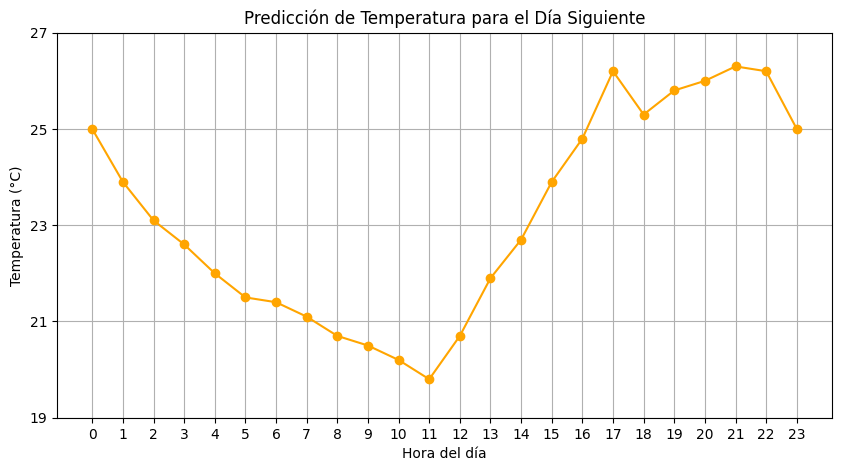

In [42]:
pred_dia_siguiente_dl_model['Hora'] = pred_dia_siguiente_dl_model['Fecha'].dt.hour

plt.figure(figsize=(10,5))
plt.plot(pred_dia_siguiente_dl_model['Hora'], pred_dia_siguiente_dl_model['Predicción_Temperatura'], marker='o', color='orange')
plt.xticks(range(0,24))
# Eje y de 2 en 2
y_min = int(np.floor(pred_dia_siguiente_dl_model['Predicción_Temperatura'].min()))
y_max = int(np.ceil(pred_dia_siguiente_dl_model['Predicción_Temperatura'].max()))
plt.yticks(np.arange(y_min, y_max+1, 2))
plt.xlabel("Hora del día")
plt.ylabel("Temperatura (°C)")
plt.title("Predicción de Temperatura para el Día Siguiente")
plt.grid(True)
plt.show()


# ***DEEP LEARNING REGRESSOR PM2.5***

In [113]:
# Definir features y target
features_PM_25 = ["uv_index","humidity","bound_lay_hei"]
features_contam = ["no2", "aero_op", "co","so2","ch4"]
#features_estacionalidad = ["sin_hour", "cos_hour", "sin_day", "cos_day"]
target_pm25 = "pm2_5"

# Dataset
df_pm = df.copy()
df_pm["date"] = pd.to_datetime(df_pm["date"])
df_pm = df_pm.sort_values("date").reset_index(drop=True)

# Variables de estacionalidad (cíclicas)
df_pm["hour"] = df_pm["date"].dt.hour
df_pm["day_of_year"] = df_pm["date"].dt.dayofyear
df_pm["sin_hour"] = np.sin(2 * np.pi * df_pm["hour"] / 24)
df_pm["cos_hour"] = np.cos(2 * np.pi * df_pm["hour"] / 24)
df_pm["sin_day"] = np.sin(2 * np.pi * df_pm["day_of_year"] / 365)
df_pm["cos_day"] = np.cos(2 * np.pi * df_pm["day_of_year"] / 365)

# Añadir pred_temp (temperatura predicha)
df_pm["pred_temp"] = np.nan
df_pm.loc[df_pm.index[-len(y_pred):], "pred_temp"] = y_pred  # alinear por fechas si es necesario

# Features finales
X_cols = features_PM_25 + features_contam + ["pred_temp"]
# + features_estacionalidad

# Quitar filas con NAs
df_pm = df_pm.dropna(subset=X_cols + [target_pm25])

X_PM = df_pm[X_cols]
y_PM = df_pm[target_pm25]

# Split train/test
X_train_pm, X_test_pm, y_train_pm, y_test_pm = train_test_split(X_PM, y_PM, test_size=0.2, shuffle=False)
dates_test_pm = df_pm["date"].iloc[-len(y_test_pm):]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_129 (Dense)               │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
Epoch 2/100
Epoch 3/100
Epoch 4/100
Epoch 5/100
Epoch 6/100
Epoch 7/100
Epoch 8/100
Epoch 9/100
Epoch 10/100
Epoch 11/100
Epoch 12/100
Epoch 13/100
Epoch 14/100
Epoch 15/100
Epoch 16/100
Epoch 17/100
Epoch 18/100
Epoch 19/100
Epoch 20/100
Epoch 21/100
Epoch 22/100
Epoch 23/100
Epoch 24/100
Epoch 25/100
Epoch 26/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Deep Learning Regressor PM2.5 - Test resultados
R² Test: 0.7918
RMSE Test: 3.6657
MAE Test: 2.6898


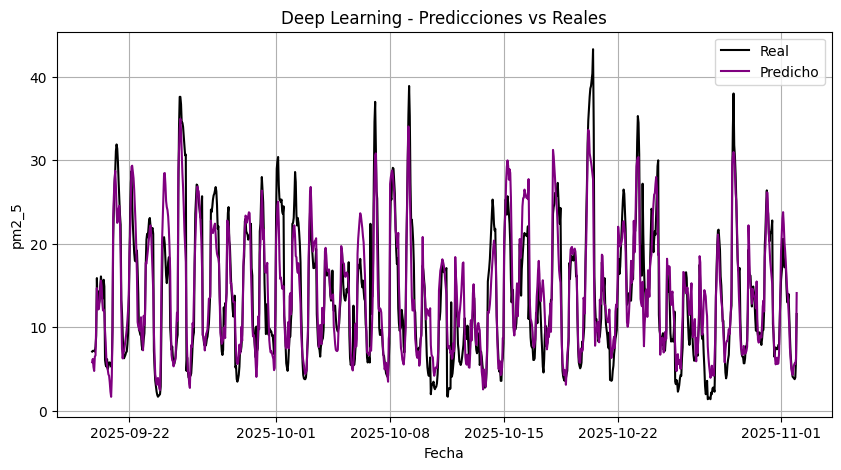

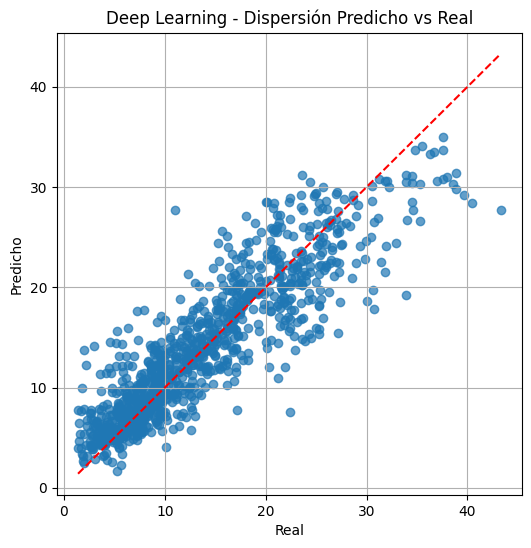

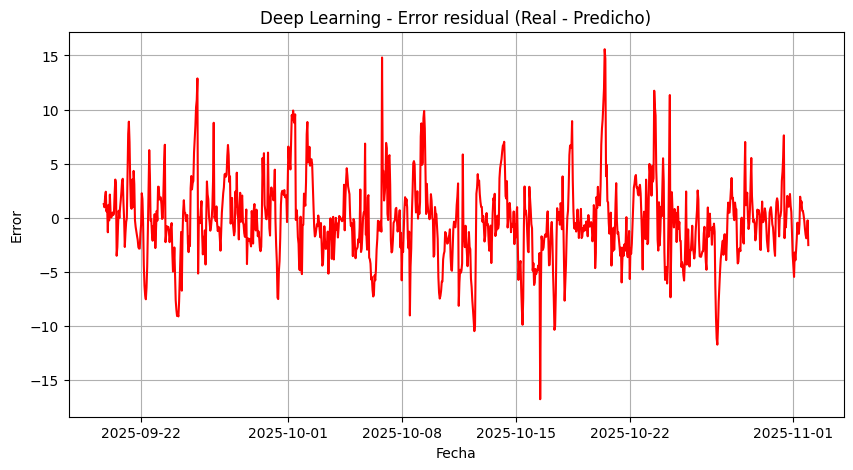

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
                       Fecha  Predicción_PM2.5
0  2025-11-02 00:00:00+00:00         19.100000
1  2025-11-02 01:00:00+00:00         21.000000
2  2025-11-02 02:00:00+00:00         23.100000
3  2025-11-02 03:00:00+00:00         23.799999
4  2025-11-02 04:00:00+00:00         22.299999
5  2025-11-02 05:00:00+00:00         20.200001
6  2025-11-02 06:00:00+00:00         19.100000
7  2025-11-02 07:00:00+00:00         17.700001
8  2025-11-02 08:00:00+00:00         16.000000
9  2025-11-02 09:00:00+00:00         14.500000
10 2025-11-02 10:00:00+00:00         13.700000
11 2025-11-02 11:00:00+00:00         12.000000
12 2025-11-02 12:00:00+00:00         10.300000
13 2025-11-02 13:00:00+00:00          7.600000
14 2025-11-02 14:00:00+00:00          6.200000
15 2025-11-02 15:00:00+00:00          5.100000
16 2025-11-02 16:00:00+00:00          4.600000
17 2025-11-02 17:00:00+00:00          4.300000
18 2025-11-02 18:00:00+00:00          5.000000
19 2025-11-02 19:00:00

/tmp/ipython-input-4241655379.py:88: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")


In [114]:
# Datos
#X_PM = df[X_cols].values
#y_PM = df[target_pm25].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_PM)

X_train_pm, X_test_pm, y_train_pm, y_test_pm = train_test_split(X_scaled, y_PM, test_size=0.2, shuffle=False)
dates_test_pm = df_pm["date"].iloc[-len(y_test_pm):]

# Semilla para reproducibilidad
tf.keras.utils.set_random_seed(42)

# Modelo Deep Learning
dl_model_pm = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_pm.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])



dl_model_pm.summary()

dl_model_pm.compile(optimizer='adam', loss='mse')


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=16, restore_best_weights=True
)

history = dl_model_pm.fit(
    X_train_pm, y_train_pm,
    validation_split=0.1,
    epochs=100,
    batch_size=100,
    callbacks=[early_stop],
    verbose=-1
)

# Predicción test
y_pred_pm = dl_model_pm.predict(X_test_pm).flatten()

r2 = r2_score(y_test_pm, y_pred_pm)
rmse = np.sqrt(mean_squared_error(y_test_pm, y_pred_pm))
mae = mean_absolute_error(y_test_pm, y_pred_pm)

print("Deep Learning Regressor PM2.5 - Test resultados")
print(f"R² Test: {r2:.4f}")
print(f"RMSE Test: {rmse:.4f}")
print(f"MAE Test: {mae:.4f}")

# Gráficas
plt.figure(figsize=(10,5))
plt.plot(dates_test_pm, y_test_pm, label="Real", color='black')
plt.plot(dates_test_pm, y_pred_pm, label="Predicho", color='purple')
plt.title("Deep Learning - Predicciones vs Reales")
plt.xlabel("Fecha")
plt.ylabel(target_pm25)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_test_pm, y_pred_pm, alpha=0.7)
plt.plot([y_test_pm.min(), y_test_pm.max()], [y_test_pm.min(), y_test_pm.max()], 'r--')
plt.title("Deep Learning - Dispersión Predicho vs Real")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(dates_test_pm, y_test_pm - y_pred_pm, color='red')
plt.title("Deep Learning - Error residual (Real - Predicho)")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.grid(True)
plt.show()

# Predicción del día siguiente (24 horas)
ultimo_dia_pm = X_scaled[-24:]  # últimas 24 horas
predicciones_siguientes_pm = dl_model_pm.predict(ultimo_dia_pm).flatten()

ultimo_dia_completo = df_pm["date"].iloc[-1].normalize()
dia_siguiente = ultimo_dia_completo + pd.Timedelta(days=1)
fechas_pred = pd.date_range(dia_siguiente, periods=24, freq="H")

pred_dia_siguiente_dl_model_pm = pd.DataFrame({
    "Fecha": fechas_pred,
    "Predicción_PM2.5": np.round(predicciones_siguientes_pm, 1)
})

print(pred_dia_siguiente_dl_model_pm)


**RECORDANDO CORRELACIONES ENTRE VARIABLES PARA ESCOGER FEATURES**

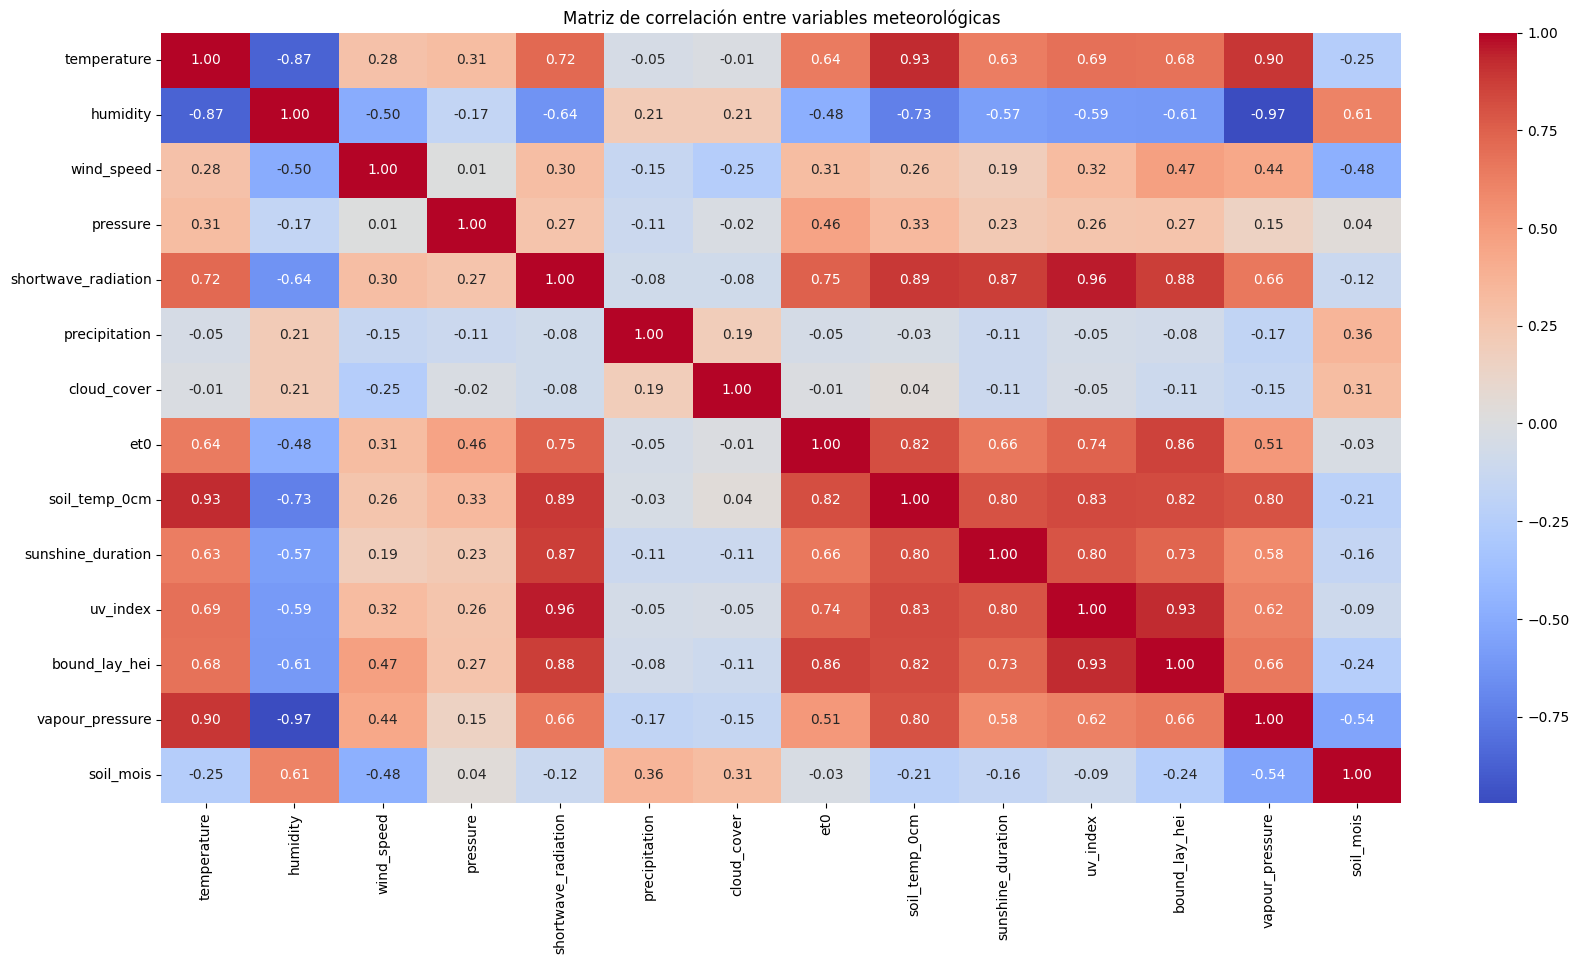

In [ ]:
# B. Relación entre variables meteorológicas
vars_corr = ["temperature","humidity","wind_speed","pressure","shortwave_radiation","precipitation","cloud_cover","et0","soil_temp_0cm",
             "sunshine_duration","uv_index","bound_lay_hei","vapour_pressure","soil_mois"]
corr = df_full[vars_corr].corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables meteorológicas")
plt.show()


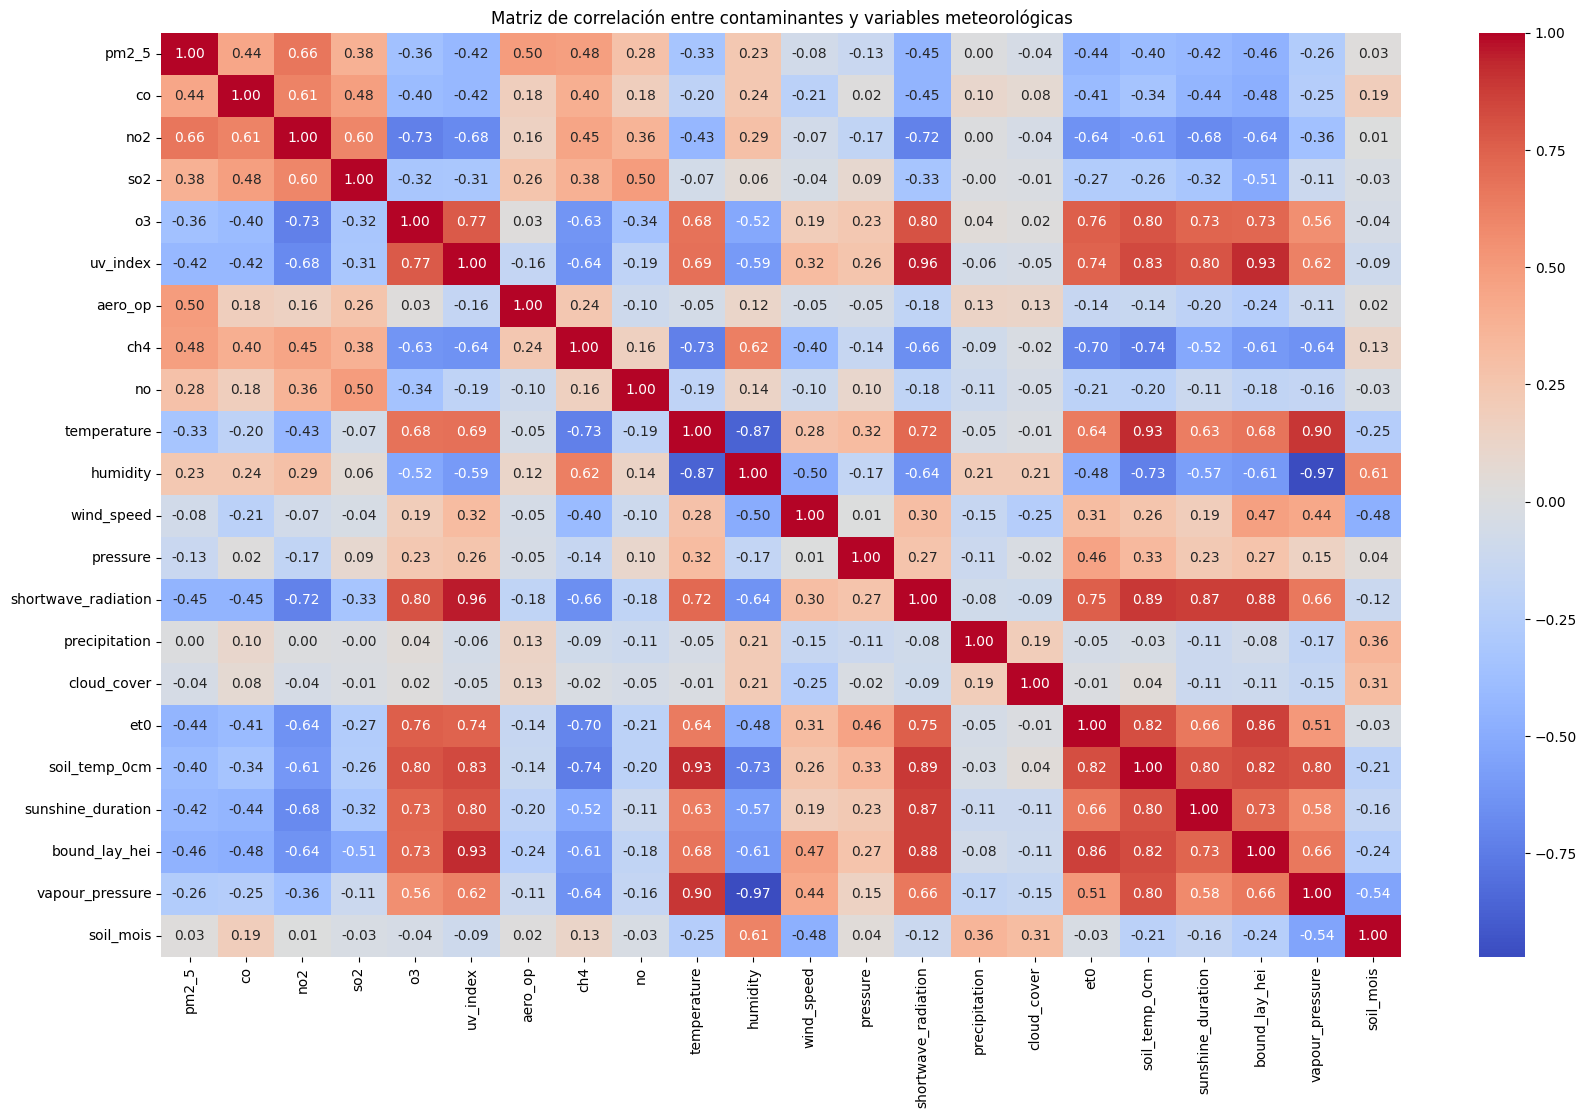

In [ ]:
# Lista completa de todas las variables
vars_corr = [
    "pm2_5", "co", "no2", "so2", "o3", "uv_index", "aero_op", "ch4",
     "no",
    "temperature", "humidity", "wind_speed", "pressure", "shortwave_radiation",
    "precipitation", "cloud_cover", "et0", "soil_temp_0cm", "sunshine_duration",
   "bound_lay_hei", "vapour_pressure", "soil_mois"
]

# Calcular la matriz de correlación
corr2 = df_full[vars_corr].corr()

# Graficar heatmap
plt.figure(figsize=(20,12))
sns.heatmap(corr2, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre contaminantes y variables meteorológicas")
plt.show()



**COMPARACIÓN DE LA PREDICIÓN CONTRA UN DÍA REAL QUE YA PASÓ**


Comparación Predicción vs Real - Último día
R²: 0.1226
RMSE: 2.4207
MAE: 2.2437


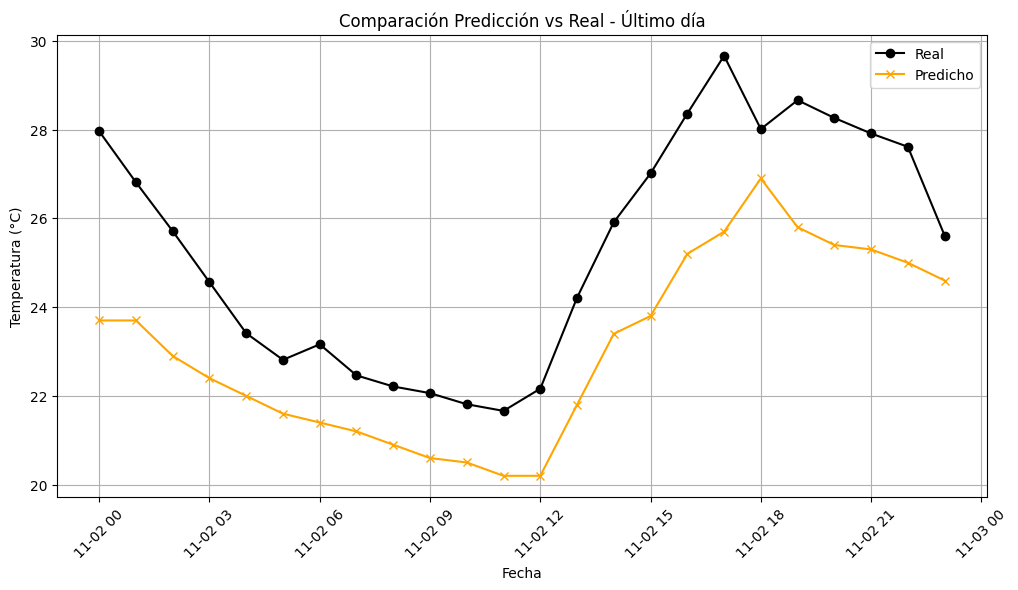

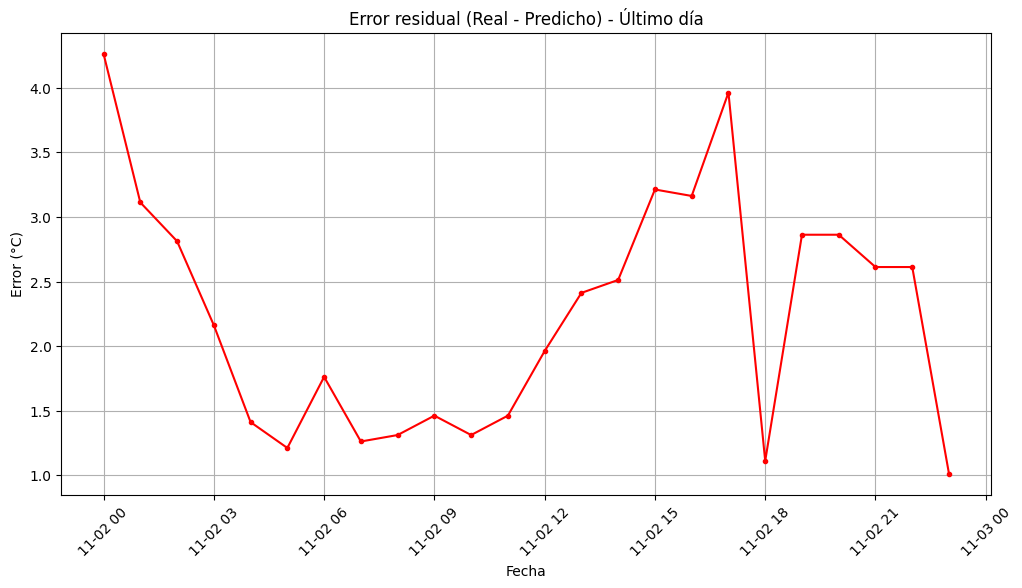

In [ ]:
# Asegurarse de que las fechas coincidan con las predicciones
df_pred = pred_dia_siguiente.copy()
df_pred["Fecha"] = pd.to_datetime(df_pred["Fecha"])

# Merge por fecha
df_comp = pd.merge(df_ultimo_dia, df_pred, left_on="date", right_on="Fecha")
df_comp = df_comp[["date", "temperature", "Predicción_Temperatura"]]

# Métricas de error
y_real = df_comp["temperature"].values
y_pred = df_comp["Predicción_Temperatura"].values

rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae = mean_absolute_error(y_real, y_pred)
r2 = (1 - (np.sum((y_real - y_pred)**2) / np.sum((y_real - np.mean(y_real))**2)))

print("\nComparación Predicción vs Real - Último día")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# Gráfica de comparación
plt.figure(figsize=(12,6))
plt.plot(df_comp["date"], y_real, label="Real", color="black", marker='o')
plt.plot(df_comp["date"], y_pred, label="Predicho", color="orange", marker='x')
plt.title("Comparación Predicción vs Real - Último día")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# Gráfica del error residual
plt.figure(figsize=(12,6))
plt.plot(df_comp["date"], y_real - y_pred, color="red", marker='.')
plt.title("Error residual (Real - Predicho) - Último día")
plt.xlabel("Fecha")
plt.ylabel("Error (°C)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()



In [ ]:
from sklearn.inspection import permutation_importance

def plot_feature_importance(model, X, y, model_name):
    """
    Obtiene y grafica la importancia de las features para un modelo dado.
    """
    # Si el modelo tiene feature_importances_ (Random Forest, Decision Tree)
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature_names = X.columns
    # Si el modelo tiene coef_ (Linear Regression, SVM lineal)
    elif hasattr(model, "coef_"):
        importances = abs(model.coef_).flatten()
        feature_names = X.columns
    else:
        # Para otros modelos (Deep Learning, SVM no lineal)
        result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
        importances = result.importances_mean
        feature_names = X.columns

    # Crear DataFrame para graficar
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp = df_imp.sort_values("Importance", ascending=False)

    # Gráfica
    plt.figure(figsize=(8,5))
    plt.barh(df_imp["Feature"], df_imp["Importance"], color="orange")
    plt.gca().invert_yaxis()
    plt.title(f"Importancia de Features - {model_name}")
    plt.xlabel("Importancia")
    plt.ylabel("Feature")
    plt.show()

    return df_imp


In [ ]:
# Ejemplo de uso con tu Random Forest entrenado
plot_feature_importance(rf_model, X_train, y_train, "Random Forest")

NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

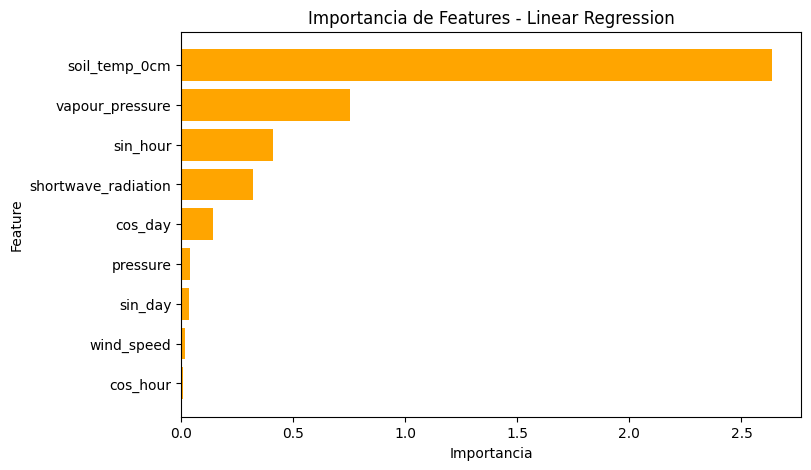

,Feature,Importance
0,soil_temp_0cm,2.634060
1,vapour_pressure,0.753486
7,sin_hour,0.408182
2,shortwave_radiation,0.323098
6,cos_day,0.140823
3,pressure,0.037959
5,sin_day,0.037091
4,wind_speed,0.017207
8,cos_hour,0.008791


In [ ]:
#lr_model,rf_model,dt_model,svm_model,dl_model
#Ejemplo con Linear Regression
plot_feature_importance(lr_model, X_train, y_train, "Linear Regression")

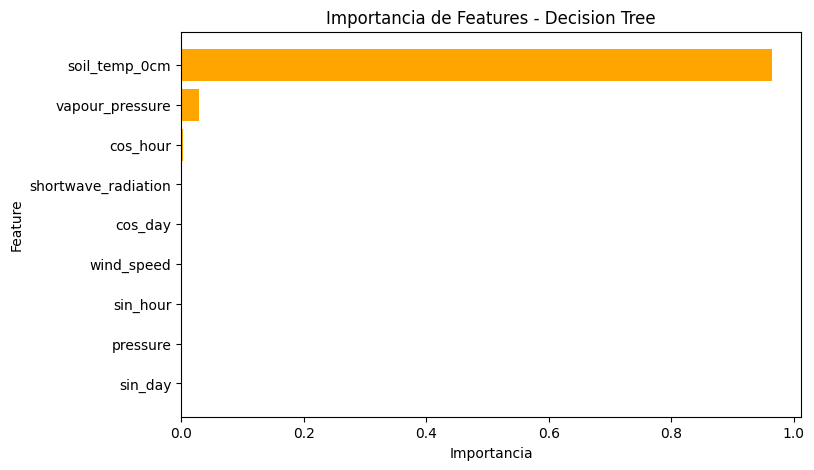

,Feature,Importance
0,soil_temp_0cm,0.963601
1,vapour_pressure,0.028935
8,cos_hour,0.003323
2,shortwave_radiation,0.001959
6,cos_day,0.001148
4,wind_speed,0.000439
7,sin_hour,0.000338
3,pressure,0.000134
5,sin_day,0.000124


In [ ]:
# Ejemplo con Decision Tree
plot_feature_importance(dt_model, X_train, y_train, "Decision Tree")

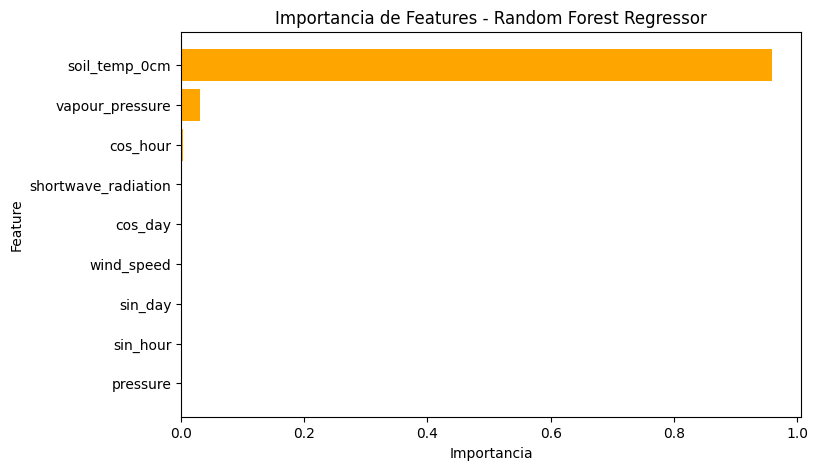

,Feature,Importance
0,soil_temp_0cm,0.958310
1,vapour_pressure,0.029992
8,cos_hour,0.003972
2,shortwave_radiation,0.002180
6,cos_day,0.001805
4,wind_speed,0.001461
5,sin_day,0.000822
7,sin_hour,0.000799
3,pressure,0.000659


In [ ]:
# Ejemplo con Random Forest (usando permutation importance)
plot_feature_importance(rf_model, X_train, y_train, "Random Forest Regressor")

In [ ]:
# Ejemplo con SVM (usando permutation importance)
plot_feature_importance(svm_model, X_train, y_train, "SVM Regressor")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVR was fitted without feature names
  warnings.warn(


KeyboardInterrupt: 

ExactExplainer explainer: 5193it [01:49, 45.19it/s]                          
/tmp/ipython-input-429636625.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar")


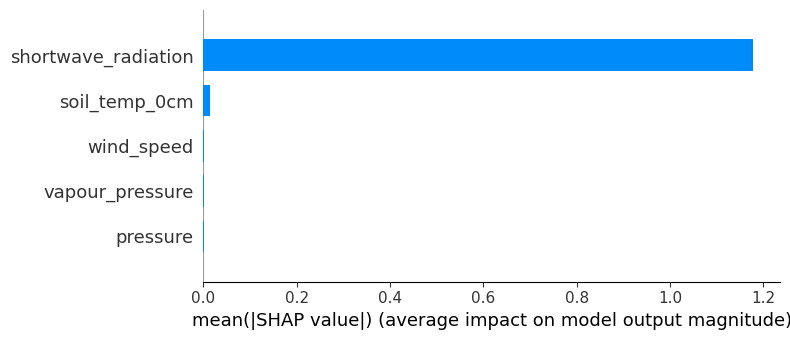

In [ ]:
import shap
# Ejemplo con Deep Learning
# Crear explainer para un modelo denso de Keras
explainer = shap.Explainer(dl_model, X_train)

# Calcular valores SHAP para el conjunto de prueba
shap_values = explainer(X_test)

# Plot resumen global de importancias
feature_names = features_reducidas  # tus nombres de columnas
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar")
